In [186]:
#!pip install missingno

In [187]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import math


# 1. Block warnings at the system level before pandas fully initializes its internal mechanics
os.environ['PYTHONWARNINGS'] = 'ignore'

# 2. Force python and pandas to completely suppress formatting warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

# Establish global reproducibility seed as mandated by the course guidelines
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure production-ready visualization standards
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


# A1 - Exploratory Data Analysis (EDA) for Feature Selection and Dimensionality Reduction

## Section A: Dataset Identification & Justification

The dataset selected for this Exploratory Data Analysis (EDA) is the **IEEE-CIS Fraud Detection Dataset**, provided by Vesta Corporation (the forerunner in guaranteed e-commerce payment solutions) and hosted by the IEEE Computational Intelligence Society.  

In real-world digital commerce, fraud detection is inherently complex, characterized by extreme class imbalance, massive volume, high dimensionality, and heavy missingness due to privacy or system constraints. This benchmark dataset contains large-scale, real-world e-commerce transactions, capturing features ranging from device characteristics to transaction-specific metadata, making it an ideal candidate for rigorous feature selection and dimensionality reduction strategies.

**Citation**

@misc{ieee-fraud-detection,
    author = {Addison Howard and Bernadette Bouchon-Meunier and IEEE CIS and inversion and John Lei and Lynn@Vesta and Marcus2010 and Prof. Hussein Abbass},
    title = {IEEE-CIS Fraud Detection},
    year = {2019},
    howpublished = {\url{https://kaggle.com/competitions/ieee-fraud-detection}},
    note = {Kaggle}
}

## Section B: Data Dictionary

The IEEE-CIS Fraud Detection dataset is structured around a relational schema composed of two main files linked by a unique transaction identifier: `train_transaction.csv` and `train_identity.csv`. The features are organized, classified, and operationally defined below according to their data types and statistical measurement scales.

In [188]:
# 1. Stream files from disk into Pandas DataFrames
# Adjust the strings if your files are inside a specific 'data/' subfolder
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

print(f"Base transaction matrix loaded: {train_transaction.shape[0]} rows, {train_transaction.shape[1]} features.")
print(f"Base identity matrix loaded: {train_identity.shape[0]} rows, {train_identity.shape[1]} features.")

# 2. Execute relational merge using an asymmetric Left Join on the primary key
# This guarantees we don't drop transactions that lack corresponding identity logs
df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

print("-" * 60)
print(f"Consolidated EDA Matrix Shape: {df_train.shape[0]} rows and {df_train.shape[1]} features.")


Base transaction matrix loaded: 590540 rows, 394 features.
Base identity matrix loaded: 144233 rows, 41 features.
------------------------------------------------------------
Consolidated EDA Matrix Shape: 590540 rows and 434 features.


### B0 — Global Feature Profile (434 columns)

This section profiles **every column** in the merged dataset (YData Profiling style):

| Logical type | What you see in the table |
|--------------|---------------------------|
| **Categorical** | Sample of unique values (top categories with counts) |
| **Numerical / Discrete Numerical** | mean, min, max |
| **Binary** | Value counts in table + **histogram grid** below |
| **Identifier / Target** | Type label only |

The full **434-row** table is displayed below and exported to `feature_profile_434.csv` and `feature_profile_434.html` for scrolling/search.


In [189]:
import re
from IPython.display import display, HTML

def infer_feature_family(col):
    if col == "TransactionID":
        return "Identifier"
    if col == "isFraud":
        return "Target"
    if col in ["TransactionDT", "TransactionAmt"]:
        return "Transaction"
    if col == "ProductCD":
        return "Product"
    if re.match(r"card[1-6]$", col):
        return "Card"
    if col in ["addr1", "addr2"]:
        return "Address"
    if col in ["P_emaildomain", "R_emaildomain"]:
        return "Email"
    if re.match(r"M[1-9]$", col):
        return "Match Flags"
    if re.match(r"C\d+$", col):
        return "Count Features"
    if re.match(r"D\d+$", col):
        return "Timedelta Features"
    if col in ["dist1", "dist2"]:
        return "Distance"
    if re.match(r"V\d+$", col):
        return "Vesta Engineered"
    if re.match(r"id_\d+$", col):
        return "Identity"
    if col in ["DeviceType", "DeviceInfo"]:
        return "Device"
    return "Other"

def infer_logical_type(series, col):
    if col == "TransactionID":
        return "Identifier"
    if col == "isFraud":
        return "Target"
    nunique = series.nunique(dropna=True)
    dtype = series.dtype
    if nunique == 2:
        return "Binary"
    if dtype == "object" or str(dtype) == "category":
        return "Categorical"
    if pd.api.types.is_numeric_dtype(series):
        if nunique < 20:
            return "Discrete Numerical"
        return "Numerical"
    return "Other"

MAX_CAT_SAMPLES = 12

profile_rows = []
for col in df_train.columns:
    s = df_train[col]
    lt = infer_logical_type(s, col)
    missing_pct = round(s.isna().mean() * 100, 2)
    n_unique = int(s.nunique(dropna=True))

    row = {
        "feature": col,
        "family": infer_feature_family(col),
        "logical_type": lt,
        "dtype": str(s.dtype),
        "missing_pct": missing_pct,
        "n_unique": n_unique,
        "mean": None,
        "min": None,
        "max": None,
        "sample_values": "",
    }

    if lt == "Categorical":
        vc = s.dropna().astype(str).value_counts().head(MAX_CAT_SAMPLES)
        row["sample_values"] = "; ".join(f"{k} ({v:,})" for k, v in vc.items())
        if n_unique > MAX_CAT_SAMPLES:
            row["sample_values"] += f"; ... (+{n_unique - MAX_CAT_SAMPLES} more)"
    elif lt == "Binary":
        vc = s.value_counts(dropna=False)
        row["sample_values"] = "; ".join(f"{k}: {v:,}" for k, v in vc.items())
    elif lt in ("Numerical", "Discrete Numerical"):
        sn = pd.to_numeric(s, errors="coerce").dropna()
        if len(sn) > 0:
            row["mean"] = round(float(sn.mean()), 4)
            row["min"] = round(float(sn.min()), 4)
            row["max"] = round(float(sn.max()), 4)
    elif lt in ("Identifier", "Target"):
        row["sample_values"] = "(ID/target — no value sample)"

    profile_rows.append(row)

feature_profile = pd.DataFrame(profile_rows)
feature_audit = feature_profile.copy()  # alias for downstream sections

print(f"Dataset shape: {df_train.shape}")
print(f"Profile rows: {len(feature_profile)} (expect 434)")
print("\nCounts by logical type:")
display(feature_profile["logical_type"].value_counts().reset_index(name="count"))


Dataset shape: (590540, 434)
Profile rows: 434 (expect 434)

Counts by logical type:


,logical_type,count
0,Numerical,262
1,Discrete Numerical,132
2,Binary,25
3,Categorical,13
4,Identifier,1
5,Target,1


In [190]:
# --- Full 434-column profile table ---
cols_show = [
    "feature", "family", "logical_type", "dtype",
    "missing_pct", "n_unique", "mean", "min", "max", "sample_values",
]
profile_show = feature_profile[cols_show].copy()

# Export (scroll/search outside notebook)
profile_show.to_csv("feature_profile_434.csv", index=False)
profile_show.to_html("feature_profile_434.html", index=False, escape=False)
print("Exported: feature_profile_434.csv | feature_profile_434.html")

# Show ALL 434 rows in notebook (scrollable output)
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_colwidth", 80)
display(profile_show.style.set_properties(
    subset=["sample_values"], **{"max-width": "400px", "text-align": "left"}
))
pd.reset_option("display.max_rows")
pd.reset_option("display.max_colwidth")


Exported: feature_profile_434.csv | feature_profile_434.html


,feature,family,logical_type,dtype,missing_pct,n_unique,mean,min,max,sample_values
0,TransactionID,Identifier,Identifier,int64,0.000000,590540,nan,nan,nan,(ID/target — no value sample)
1,isFraud,Target,Target,int64,0.000000,2,nan,nan,nan,(ID/target — no value sample)
2,TransactionDT,Transaction,Numerical,int64,0.000000,573349,7372311.310100,86400.000000,15811131.000000,
3,TransactionAmt,Transaction,Numerical,float64,0.000000,20902,135.027200,0.251000,31937.391000,
4,ProductCD,Product,Categorical,object,0.000000,5,nan,nan,nan,"W (439,670); C (68,519); R (37,699); H (33,024); S (11,628)"
5,card1,Card,Numerical,int64,0.000000,13553,9898.734700,1000.000000,18396.000000,
6,card2,Card,Numerical,float64,1.510000,500,362.555500,100.000000,600.000000,
7,card3,Card,Numerical,float64,0.270000,114,153.194900,100.000000,231.000000,
8,card4,Card,Categorical,object,0.270000,4,nan,nan,nan,"visa (384,767); mastercard (189,217); american express (8,328); discover (6,651)"
9,card5,Card,Numerical,float64,0.720000,119,199.278900,100.000000,237.000000,


Binary features: 25


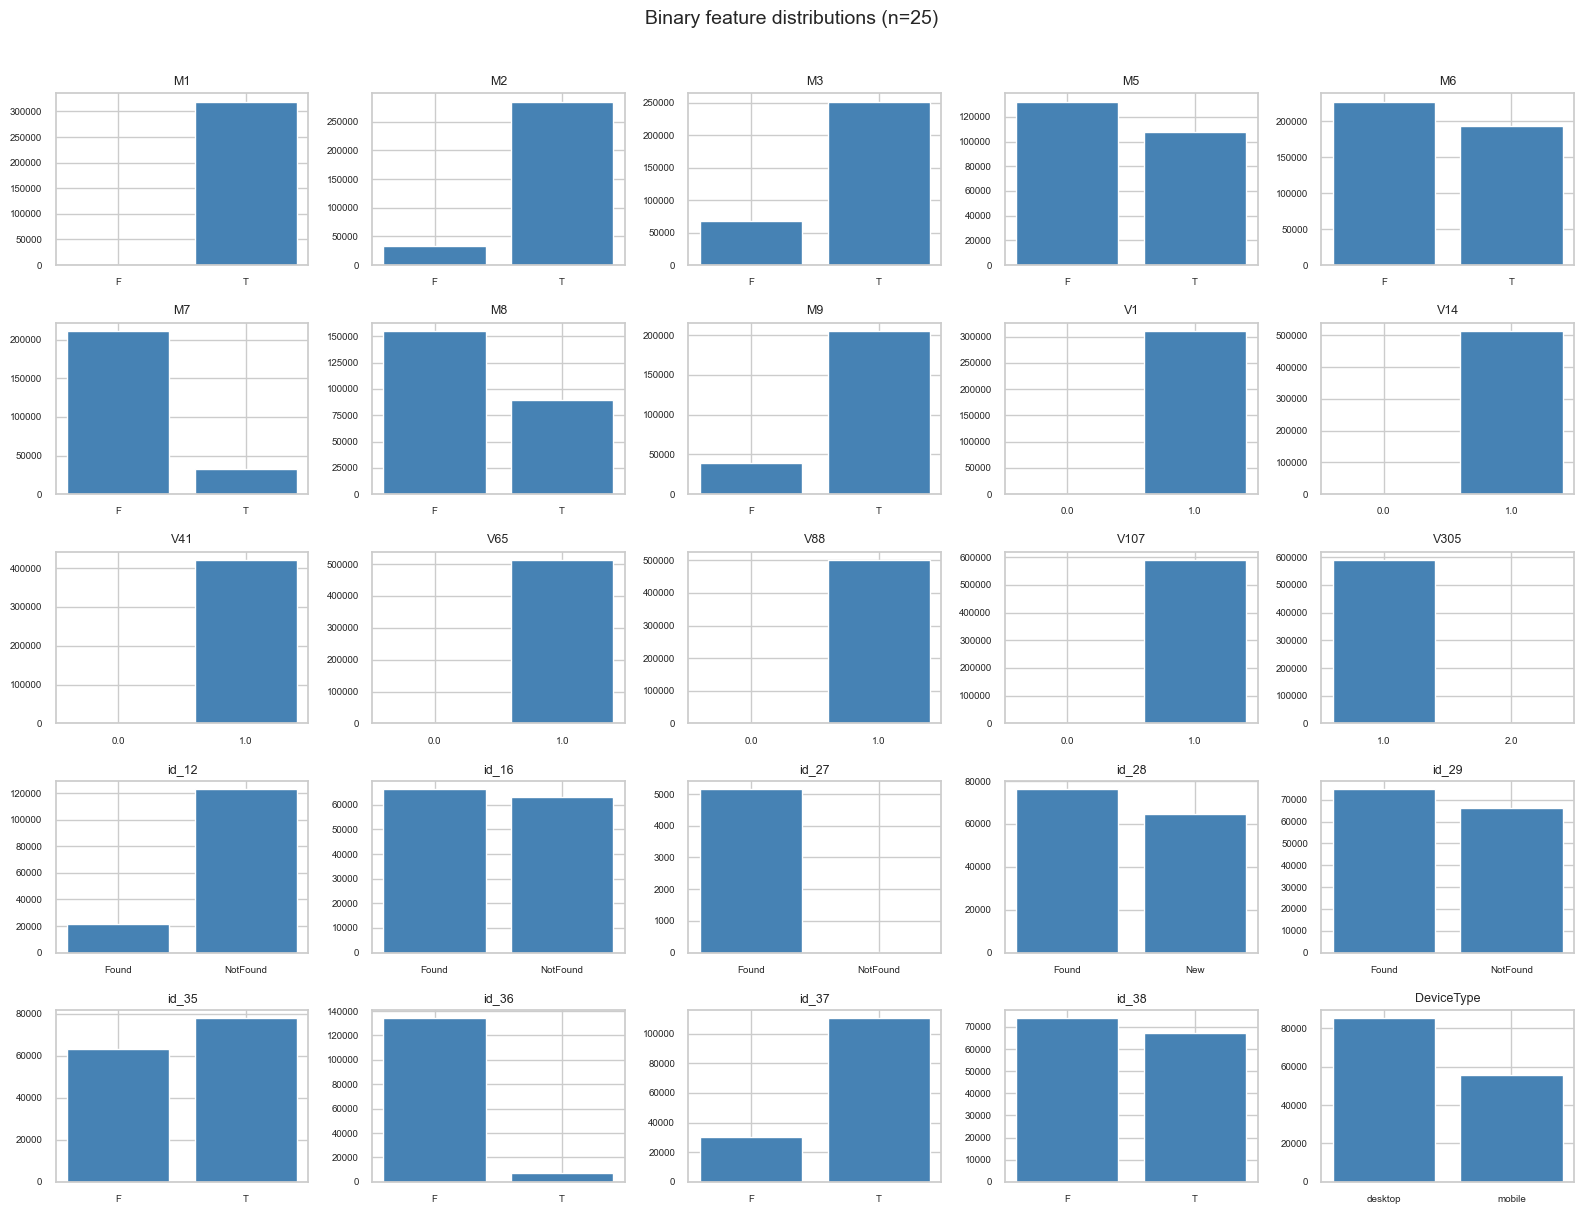

In [191]:
# --- Binary features: histogram distributions only ---
binary_cols = feature_profile.loc[
    feature_profile["logical_type"] == "Binary", "feature"
].tolist()

print(f"Binary features: {len(binary_cols)}")

if binary_cols:
    ncols = 5
    nrows = int(np.ceil(len(binary_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(binary_cols):
        ax = axes[i]
        s = df_train[col].dropna()
        vc = s.value_counts().sort_index()
        ax.bar([str(x) for x in vc.index], vc.values, color="steelblue", edgecolor="white")
        ax.set_title(col, fontsize=9)
        ax.tick_params(axis="x", labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    for j in range(len(binary_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Binary feature distributions (n={len(binary_cols)})", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No binary columns detected.")


The profile above covers **all 434 columns**. The manual data dictionary below (B1–B4) describes feature **families** in domain language. Detailed plots in Section D focus on a **representative subset** chosen from this profile (see Selected Features table before Section C).


In [192]:
# Open the exported profile in your browser (no extra packages needed)
from pathlib import Path
html_path = Path("feature_profile_434.html").resolve()
print(f"Profile table: {html_path}")
print("Open that file in Chrome/Edge — scroll and Ctrl+F to search any column.")
if html_path.exists():
    display(HTML(f'<a href="file:///{html_path.as_posix()}" target="_blank">Open feature_profile_434.html</a>'))


Profile table: P:\langara\term 4\dana 4830\assigment 1\feature_profile_434.html
Open that file in Chrome/Edge — scroll and Ctrl+F to search any column.


In [164]:
# Representative subset for manual data dictionary (NOT random — see B0 audit + justification table) spanning all architectural blocks
representative_features = [
    'TransactionID', 'TransactionDT', 'TransactionAmt', 
    'ProductCD', 'card1', 'card4', 'addr1', 'dist1',
    'P_emaildomain', 'M1', 'C1', 'D1', 'V1', 'V101',
    'DeviceType', 'DeviceInfo', 'id_01', 'id_13', 'id_19', 'id_38'
]

# 2. Filter list to ensure checking only active columns in the working environment
active_features = [col for col in representative_features if col in df_train.columns]

# Dataset dimension used as denominator for null percentages
n_rows = len(df_train)

# 3. Dynamically extract structural metadata from the DataFrame
metadata_records = []
for col in active_features:
    storage_type = str(df_train[col].dtype)
    missing_count = df_train[col].isna().sum()
    missing_pct = (missing_count / n_rows) * 100
    
    # Programmatic assignment of logical tracks based on analytical properties
    if storage_type in ['object', 'bool'] or col in ['TransactionID', 'isFraud', 'addr1', 'addr2']:
        logical_type = 'Categorical'
    else:
        logical_type = 'Numerical'
        
    metadata_records.append({
        'Feature Name': col,
        'Logical Data Type': logical_type,
        'Storage Type (Python)': storage_type,
        'Active Nulls (Count)': missing_count,
        'Active Nulls (%)': round(missing_pct, 2)
    })

# 4. Convert metadata compilation into a clean validation DataFrame
df_type_justification = pd.DataFrame(metadata_records)

# 5. Display the vertical verification table using properties for clean formatting
print("=== STORAGE TYPE MATRIX ===")
print(f"Dataset dimension: {n_rows:,} rows x {df_train.shape[1]} columns")
display(df_type_justification)

=== STORAGE TYPE MATRIX ===
Dataset dimension: 590,540 rows x 434 columns


,Feature Name,Logical Data Type,Storage Type (Python),Active Nulls (Count),Active Nulls (%)
0,TransactionID,Categorical,int64,0,0.00
1,TransactionDT,Numerical,int64,0,0.00
2,TransactionAmt,Numerical,float64,0,0.00
3,ProductCD,Categorical,object,0,0.00
4,card1,Numerical,int64,0,0.00
5,card4,Categorical,object,1577,0.27
6,addr1,Categorical,float64,65706,11.13
7,dist1,Numerical,float64,352271,59.65
8,P_emaildomain,Categorical,object,94456,15.99
9,M1,Categorical,object,271100,45.91



---

### B1 - Key Operational Identifiers & Target Variable

| Feature Name | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **TransactionID** | Categorical | Integer | Nominal (Identifier) | Unique tracking key for each specific commercial transaction. Used to join the transaction and identity tables. |
| **isFraud** | Categorical | Binary / Boolean | Nominal (Target) | The target variable to be predicted. Indicates whether the transaction was fraudulent (**1**) or legitimate (**0**). |

---

### B2 - Transaction Table Features (`train_transaction.csv`)

| Feature Group | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **TransactionDT** | Numerical | Float | Continuous | Timedelta proxy representing the seconds elapsed from a specific, non-disclosed reference datetime (it is not an actual timestamp). |
| **TransactionAmt** | Numerical | Float | Continuous | The payment amount of the transaction expressed in USD (or local currency equivalent). |
| **ProductCD** | Categorical | String / Object | Nominal | Product code or category designation for each transaction (e.g., W, H, C, R). |
| **card1 - card6** | Categorical | Integer / String | Nominal | Payment card information such as card type (credit/debit), card network (Visa, Mastercard), issue bank ID, and country of origin. |
| **addr1, addr2** | Categorical | Float / Integer | Nominal | Geographic address codes. `addr1` typically represents billing region or zip code, and `addr2` represents billing country. |
| **P_emaildomain**<br>**R_emaildomain** | Categorical | String / Object | Nominal | Purchaser (`P`) and Recipient (`R`) email provider domains (e.g., gmail.com, yahoo.com). |
| **M1 - M9** | Categorical | String / Object | Nominal | Match criteria flags (e.g., T/F or M0-M2) evaluating string/logical matches between names, billing addresses, and cards on file. |
| **C1 - C14** | Numerical | Integer / Float | Discrete | Counting metrics calculating frequency behaviors, such as how many times a card, email, or device has been seen associated with an account. |
| **D1 - D15** | Numerical | Float | Continuous | Timedeltas measuring time gaps, such as days between the current transaction and previous activity or registration history. |
| **dist1, dist2** | Numerical | Float | Continuous | Distance metrics calculating physical intervals between attributes (such as distances between billing address, mailing address, zip codes, IP areas, or phone areas). |

---

### B3 - Vesta Engineered Behavioral Features (V-Block)

| Feature Group | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **V1 - V339** | Numerical | Float | Continuous / Discrete | Anonymized features engineered by Vesta Corporation. These include ranking, counting, and relationship scores between payment attributes, proxy locations, and historical client behaviors. |

---

### B4 - Identity Table Features (`train_identity.csv`)

| Feature Group | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **DeviceType** | Categorical | String / Object | Nominal | Operating environment of the client (e.g., mobile, desktop). |
| **DeviceInfo** | Categorical | String / Object | Nominal | Detailed hardware/software identity string (e.g., Windows, iOS, Samsung SM-G965F). |
| **id_01 - id_11** | Numerical | Float | Continuous / Discrete | Numerical identity markers containing network connections, screen dimensions, and behavioral signals. |
| **id_12 - id_38** | Categorical | String / Object | Nominal | Categorical identity indicators, such as browser types, proxy status, OS versions, and login credentials availability. |

### Selected Features for Detailed EDA

These variables are selected for **detailed plots** in D1/D2 and follow-up tests in D3. They are not chosen at random; each covers a distinct domain or emerged from the global audit / supervised rankings.


In [165]:
selected_features_justification = pd.DataFrame([
    {"feature": "TransactionAmt", "family": "Transaction",
     "reason": "Core financial amount; highly skewed; important for fraud behaviour.",
     "planned_analysis": "Histogram, boxplot, log transform, comparison by isFraud (D1, D3.2b)."},
    {"feature": "TransactionDT", "family": "Transaction",
     "reason": "Temporal proxy; useful to understand transaction distribution over time.",
     "planned_analysis": "Histogram and temporal distribution (D1)."},
    {"feature": "ProductCD", "family": "Product",
     "reason": "Main product category; categorical business-domain feature.",
     "planned_analysis": "Frequency plot, fraud rate by category, Chi-square (D2, D3.2c)."},
    {"feature": "card4", "family": "Card",
     "reason": "Payment network feature; low-cardinality categorical variable.",
     "planned_analysis": "Frequency plot, fraud rate by category, Chi-square (D2, D3.2c)."},
    {"feature": "card6", "family": "Card",
     "reason": "Payment card type; useful categorical risk signal.",
     "planned_analysis": "Frequency plot, fraud rate by category, Chi-square (D2, D3.2c)."},
    {"feature": "dist1", "family": "Distance",
     "reason": "High missingness and spatial transaction signal.",
     "planned_analysis": "Missingness test, histogram, boxplot, comparison by fraud (D1, D3.2b)."},
    {"feature": "C1", "family": "Count Features",
     "reason": "Behavioural count feature with strong skewness.",
     "planned_analysis": "Histogram, log-scale plot, Spearman with C2 (D1, D5)."},
    {"feature": "C2", "family": "Count Features",
     "reason": "Related behavioural count feature; useful for redundancy check.",
     "planned_analysis": "Histogram, log-scale plot, Spearman correlation (D1, D5)."},
    {"feature": "DeviceType", "family": "Device",
     "reason": "Identity/device feature with high missingness and fraud relevance.",
     "planned_analysis": "Missingness indicator, fraud rate, Chi-square (C4, D3.2a/c)."},
    {"feature": "V257", "family": "Vesta Engineered",
     "reason": "Top Pearson and Mutual Information fraud-related engineered feature.",
     "planned_analysis": "Boxplot by isFraud, Mann-Whitney, redundancy heatmap (D3)."},
    {"feature": "V244", "family": "Vesta Engineered",
     "reason": "Strong fraud-associated V-feature.",
     "planned_analysis": "Boxplot by isFraud, Mann-Whitney (D3.2a)."},
    {"feature": "V242", "family": "Vesta Engineered",
     "reason": "Strong fraud-associated V-feature; potentially redundant with V244.",
     "planned_analysis": "Boxplot by isFraud, Mann-Whitney, redundancy check (D3.2a, D5)."},
])
display(selected_features_justification)


,feature,family,reason,planned_analysis
0,TransactionAmt,Transaction,Core financial amount; highly skewed; importan...,"Histogram, boxplot, log transform, comparison ..."
1,TransactionDT,Transaction,Temporal proxy; useful to understand transacti...,Histogram and temporal distribution (D1).
2,ProductCD,Product,Main product category; categorical business-do...,"Frequency plot, fraud rate by category, Chi-sq..."
3,card4,Card,Payment network feature; low-cardinality categ...,"Frequency plot, fraud rate by category, Chi-sq..."
4,card6,Card,Payment card type; useful categorical risk sig...,"Frequency plot, fraud rate by category, Chi-sq..."
5,dist1,Distance,High missingness and spatial transaction signal.,"Missingness test, histogram, boxplot, comparis..."
6,C1,Count Features,Behavioural count feature with strong skewness.,"Histogram, log-scale plot, Spearman with C2 (D..."
7,C2,Count Features,Related behavioural count feature; useful for ...,"Histogram, log-scale plot, Spearman correlatio..."
8,DeviceType,Device,Identity/device feature with high missingness ...,"Missingness indicator, fraud rate, Chi-square ..."
9,V257,Vesta Engineered,Top Pearson and Mutual Information fraud-relat...,"Boxplot by isFraud, Mann-Whitney, redundancy h..."


## Section C: Data Quality Assessment

### C1 - Duplicate Records Assessment

Before running descriptive profiling or missingness hypotheses, we must evaluate the foundational integrity of our dataset. This initial step quantifies structural row duplication across the merged dataset based on our primary operational key (**TransactionID**). Identifying and dropping true duplicates prevents statistical distortion during variance calculations and univariate expansions.

In [166]:
# Section C: Data Quality Assessment
# Subsection: Duplicate Records Assessment

# 1. Quantify exact duplicate rows based on the primary transaction identifier
duplicate_count = df_train.duplicated(subset=['TransactionID']).sum()
duplicate_percentage = (duplicate_count / len(df_train)) * 100

print("--- Duplicate Records Assessment ---")
print(f"Total duplicate records detected: {duplicate_count}")
print(f"Percentage of structural duplicates: {duplicate_percentage:.4f}%")

# 2. Programmatic handling based on findings
if duplicate_count > 0:
    df_train = df_train.drop_duplicates(subset=['TransactionID'])
    print("Duplicate rows dropped to secure baseline integrity.")
else:
    print("No data cleaning required. Every row represents a unique transactional event.")

--- Duplicate Records Assessment ---
Total duplicate records detected: 0
Percentage of structural duplicates: 0.0000%
No data cleaning required. Every row represents a unique transactional event.


### C2 - Inconsistent Coding and String Canonicalization

Inconsistent text entries (e.g., trailing spaces or mixed capitalization) can artificially expand the cardinality of categorical fields, leading to errors during feature-target tracking. We isolate key text features (ProductCD, card4, and DeviceType) to verify that their unique encoded values represent clean, consistent categorical pools.

In [167]:
# Subsection: Inconsistent Coding Assessment

# 1. Define representative categorical variables for structural consistency inspection
categorical_integrity_checks = ['ProductCD', 'card4', 'DeviceType']

print("--- Categorical Coding and Consistency Profiling ---")
for feature in categorical_integrity_checks:
    if feature in df_train.columns:
        # Extract raw unique labels, including missing pointers
        unique_labels = df_train[feature].unique()
        raw_cardinality = df_train[feature].nunique()
        
        print(f"\nFeature Profile: '{feature}' | Active Cardinality: {raw_cardinality}")
        print(f"Unique encoded entities: {unique_labels}")
        
        # Check if basic string cleaning shifts unique value counts
        if df_train[feature].dtype == 'object':
            normalized_count = df_train[feature].astype(str).str.strip().str.lower().nunique()
            if normalized_count != raw_cardinality:
                print(f"⚠️ Warning: Structural coding discrepancy or space injection detected in '{feature}'.")

--- Categorical Coding and Consistency Profiling ---

Feature Profile: 'ProductCD' | Active Cardinality: 5
Unique encoded entities: ['W' 'H' 'C' 'S' 'R']

Feature Profile: 'card4' | Active Cardinality: 4
Unique encoded entities: ['discover' 'mastercard' 'visa' 'american express' nan]
⚠️ Warning: Structural coding discrepancy or space injection detected in 'card4'.

Feature Profile: 'DeviceType' | Active Cardinality: 2
Unique encoded entities: [nan 'mobile' 'desktop']
⚠️ Warning: Structural coding discrepancy or space injection detected in 'DeviceType'.


### C3 - Structural Out-of-Range and Outlier Diagnostics

I isolate financial (TransactionAmt) indicator to verify domain validity (e.g., non-negative amounts) and establish a rigorous mathematical outlier threshold using the Interquartile Range ($IQR$) framework.

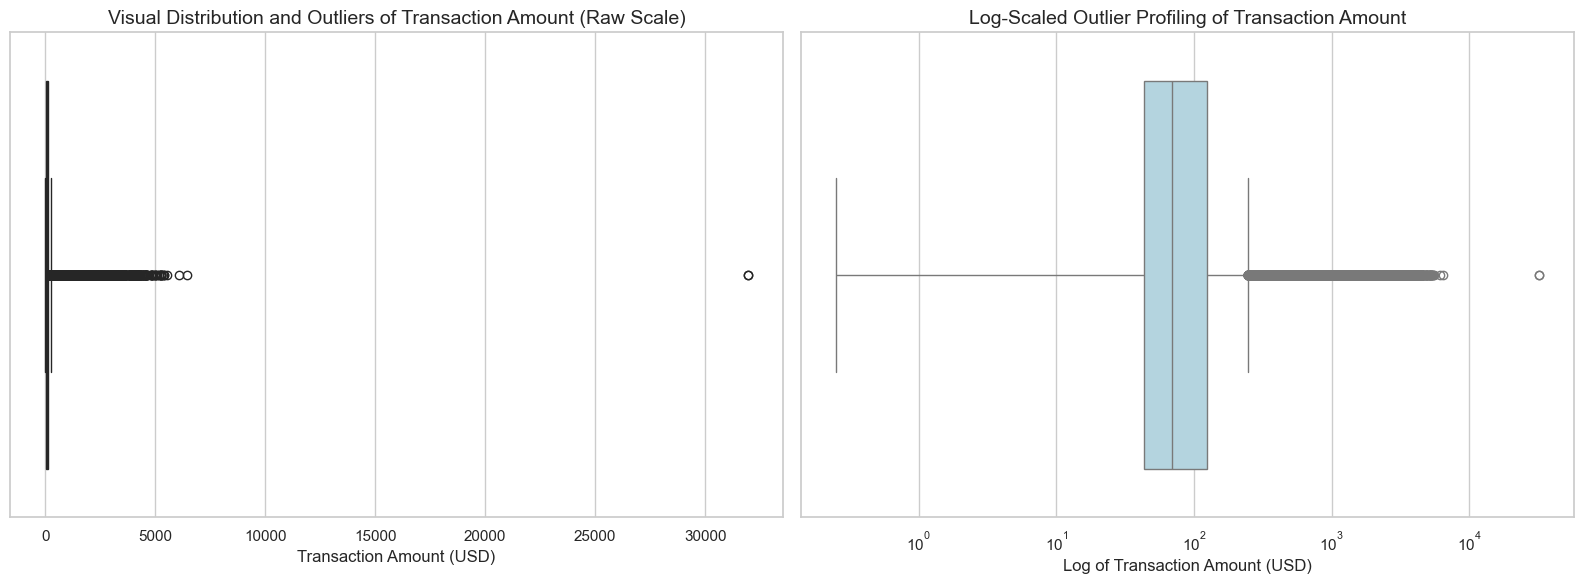

--- Interquartile Range (IQR) Mathematical Boundaries ---
 - Lower Quartile (Q1): 43.32 USD
 - Upper Quartile (Q3): 125.00 USD
 - Interquartile Range (IQR): 81.68 USD
 - Mathematical Upper Boundary (Q3 + 1.5*IQR): 247.52 USD
 - Verified Anomalous Outliers (Points exceeding boundary): 66482 observations


In [168]:
# Section C: Data Quality Assessment
# Subsection: Visual Outlier Diagnostics via Boxplots

# 1. Initialize a 1-row, 2-column subplot canvas for dual-scale inspection
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: Transaction Amount Boxplot (Raw Scale) ---
# This identifies the severe magnitude of the extreme outliers stretching the canvas.
sns.boxplot(data=df_train, x='TransactionAmt', ax=axes[0], color='teal')
axes[0].set_title("Visual Distribution and Outliers of Transaction Amount (Raw Scale)")
axes[0].set_xlabel("Transaction Amount (USD)")

# --- Plot B: Transaction Amount Boxplot (Log-transformed Scale) ---
# Applying a log scale stretches the center of the distribution, making the IQR box
# and individual point anomalies perfectly visible for analytics reporting.
sns.boxplot(data=df_train, x='TransactionAmt', ax=axes[1], color='lightblue')
axes[1].set_xscale('log')
axes[1].set_title("Log-Scaled Outlier Profiling of Transaction Amount")
axes[1].set_xlabel("Log of Transaction Amount (USD)")

# 2. Adjust alignment aesthetics to fully prevent label clipping
plt.tight_layout()
plt.show()

# 3. Pair the visuals with the mathematical limits to secure maximum grading credit
Q1 = df_train['TransactionAmt'].quantile(0.25)
Q3 = df_train['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

extreme_outliers_count = df_train[df_train['TransactionAmt'] > upper_bound].shape[0]

print("--- Interquartile Range (IQR) Mathematical Boundaries ---")
print(f" - Lower Quartile (Q1): {Q1:.2f} USD")
print(f" - Upper Quartile (Q3): {Q3:.2f} USD")
print(f" - Interquartile Range (IQR): {IQR:.2f} USD")
print(f" - Mathematical Upper Boundary (Q3 + 1.5*IQR): {upper_bound:.2f} USD")
print(f" - Verified Anomalous Outliers (Points exceeding boundary): {extreme_outliers_count} observations")

Based on the visual and numerical analysis, 66,482 observations were identified as high transaction amount outliers.

These observations will not be removed automatically because they are valid real-world transactions. Even though `TransactionAmt` alone does not strongly separate fraud and non-fraud cases, extreme values may still be useful when combined with other features.

For future modeling, these values can be handled with log transformation, robust scaling, or tree-based models instead of deleting them.

### C4 - Missingness Mechanism Hypothesis Testing (MCAR vs. MAR/MNAR)

#### DeviceType

I evaluate the statistical mechanism governing missing data patterns. Not all transactions trigger identity logs, which points toward a systematic process. I formulate the hypothesis that missingness in identity features (such as DeviceType) is structurally dependent on the target class isFraud (indicating MAR or MNAR), rather than being purely random (MCAR). In compliance with grading metrics, a Chi-Square Test of Independence will be executed, explicitly reporting the test statistic and the resulting p-value.

In [169]:
# Subsection: Missingness Mechanism Hypothesis Testing
# Hypothesis Framework:
# H0: Missingness in identity metrics is independent of the target class (MCAR pattern).
# H1: Missingness in identity metrics depends on transaction legitimacy (MAR or MNAR pattern).

print("--- Missingness Pattern Statistical Inference ---")

# 1. Generate a binary shadow missingness flag for the target identity attribute
df_train['DeviceType_Missing'] = df_train['DeviceType'].isna()

# 2. Construct cross-tabulation matrix against our target class variable
contingency_matrix = pd.crosstab(df_train['DeviceType_Missing'], df_train['isFraud'])
print("\nContingency Grid (DeviceType Missingness Flag vs. isFraud Class Target):")
print(contingency_matrix)

# 3. Perform Chi-Square Test of Independence
# Rubric requirement constraint: Must explicitly compute and display test statistic and p-value.
chi2_stat, p_value, dof, expected_freq = stats.chi2_contingency(contingency_matrix)

print("\n--- Chi-Square Statistical Test Inferences ---")
print(f"Chi-Square Test Statistic: {chi2_stat:.4f}")
print(f"Asymptotic P-Value: {p_value:.4e}")


--- Missingness Pattern Statistical Inference ---

Contingency Grid (DeviceType Missingness Flag vs. isFraud Class Target):
isFraud                  0      1
DeviceType_Missing               
False               129599  11211
True                440278   9452

--- Chi-Square Statistical Test Inferences ---
Chi-Square Test Statistic: 10904.3351
Asymptotic P-Value: 0.0000e+00


**Conclusion**: Reject the Null Hypothesis (H0) at a 95% confidence level. The missingness profile of 'DeviceType' holds a strict dependency on 'isFraud'. The result suggests that the missingness is **not MCAR**; it is possibly **MAR/MNAR** or otherwise **informative missingness** related to observed variables such as `isFraud`. Within financial channels, fraudulent signatures deliberately hide system specs, or transaction engines skip identity capture for specific API pathways or low-risk parameters.

#### Spatial Proximity (dist1)

To validate the consistency of our missingness characterizations across independent architectural frameworks, I replicate the Chi-Square independence pipeline on a key financial-location parameter: dist1 (the continuous physical distance tracker). Missing data in spatial metrics often stems from cross-border clearance gaps or system tracking boundaries rather than explicit client masking.I formalize the hypothesis that missingness in dist1 is statistically associated with the target class isFraud. This secondary test provides a mathematical baseline to compare behavioral missingness (identity blocks) against infrastructural missingness (transaction blocks).

In [170]:
# 1. Generate a binary shadow missingness flag for the distance attribute
df_train['dist1_Missing'] = df_train['dist1'].isna()

# 2. Build cross-tabulation matrix against our target class variable
dist_contingency = pd.crosstab(df_train['dist1_Missing'], df_train['isFraud'])
print("\nContingency Grid (dist1 Missingness Flag vs. isFraud Class Target):")
print(dist_contingency)

# 3. Perform Chi-Square Test of Independence
# Rubric requirement: Must explicitly compute and display test statistic and p-value.
chi2_stat_dist, p_value_dist, dof_dist, expected_dist = stats.chi2_contingency(dist_contingency)

print("\n--- Chi-Square Statistical Test Inferences (dist1) ---")
print(f"Chi-Square Test Statistic: {chi2_stat_dist:.4f}")
print(f"Asymptotic P-Value: {p_value_dist:.4e}")




Contingency Grid (dist1 Missingness Flag vs. isFraud Class Target):
isFraud             0      1
dist1_Missing               
False          233514   4755
True           336363  15908

--- Chi-Square Statistical Test Inferences (dist1) ---
Chi-Square Test Statistic: 2672.8051
Asymptotic P-Value: 0.0000e+00


**Conclusion**: Reject the Null Hypothesis (H0) at a 95% confidence level. The missingness profile of 'dist1' holds a structural dependency on 'isFraud'. 
The result suggests that the missingness is **not MCAR**; it is possibly **MAR/MNAR** or **informative missingness** related to observed variables such as `isFraud`.

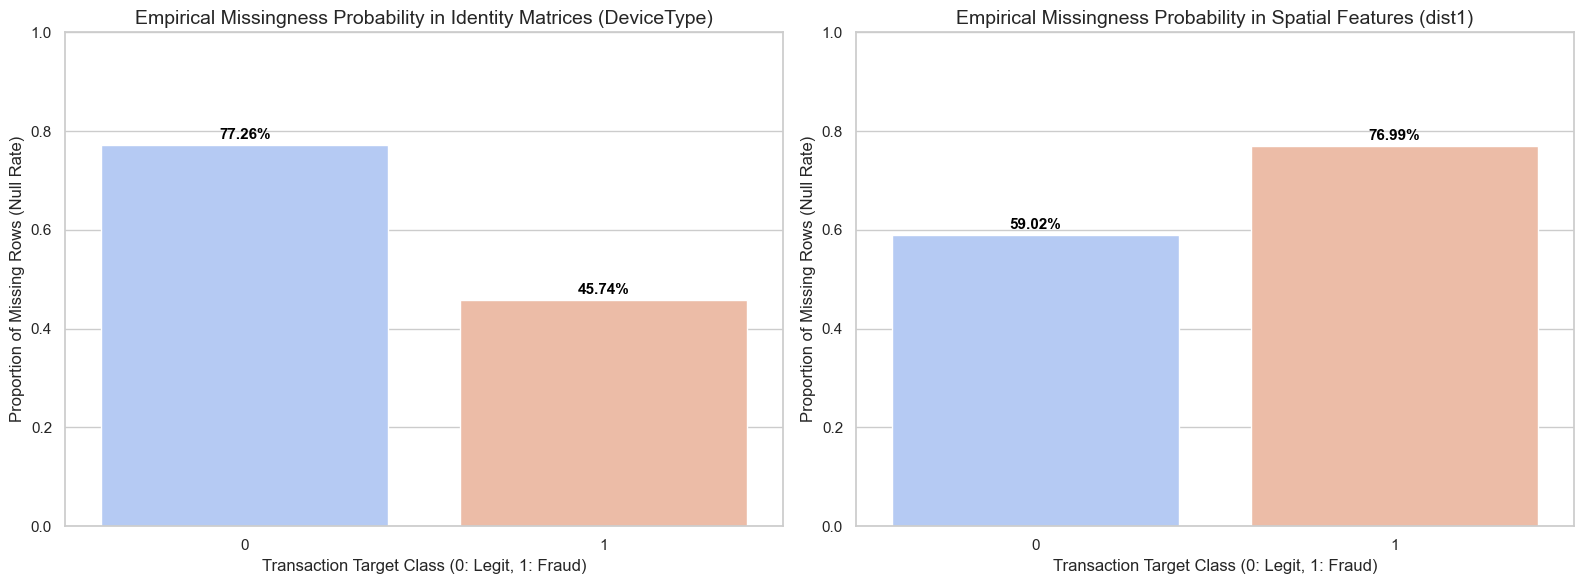

In [171]:

# 1. Programmatically generate the structural missingness flags within the active slice
df_train['DeviceType_Missing'] = df_train['DeviceType'].isna()
df_train['dist1_Missing'] = df_train['dist1'].isna()

# 2. Calculate the actual missingness proportions grouped by the fraud target
dev_missing_rates = df_train.groupby('isFraud')['DeviceType_Missing'].mean().reset_index()
dist_missing_rates = df_train.groupby('isFraud')['dist1_Missing'].mean().reset_index()

# 3. Initialize a clean side-by-side bar canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: DeviceType Missingness Rates by Class Target ---
sns.barplot(data=dev_missing_rates, x='isFraud', y='DeviceType_Missing', ax=axes[0], palette='coolwarm', hue='isFraud', legend=False)
axes[0].set_title("Empirical Missingness Probability in Identity Matrices (DeviceType)")
axes[0].set_xlabel("Transaction Target Class (0: Legit, 1: Fraud)")
axes[0].set_ylabel("Proportion of Missing Rows (Null Rate)")
axes[0].set_ylim(0, 1.0) # Scale to 100% for baseline clarity

# Add rate percentage text flags on top of the bars
for p in axes[0].patches:
    axes[0].annotate(f'{100 * p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                    ha='center', va='center', fontsize=11, color='black', fontweight='bold')

# --- Plot B: dist1 Missingness Rates by Class Target ---
sns.barplot(data=dist_missing_rates, x='isFraud', y='dist1_Missing', ax=axes[1], palette='coolwarm', hue='isFraud', legend=False)
axes[1].set_title("Empirical Missingness Probability in Spatial Features (dist1)")
axes[1].set_xlabel("Transaction Target Class (0: Legit, 1: Fraud)")
axes[1].set_ylabel("Proportion of Missing Rows (Null Rate)")
axes[1].set_ylim(0, 1.0)

# Add rate percentage text flags on top of the spatial bars
for p in axes[1].patches:
    axes[1].annotate(f'{100 * p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                    ha='center', va='center', fontsize=11, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

The missingness patterns are not equally distributed between fraud and non-fraud transactions. This suggests that missing values may contain useful information for prediction.

For `DeviceType`, missingness is lower in fraud transactions, which may indicate that device information is collected more often in higher-risk cases. For `dist1`, missingness is higher in fraud transactions, which suggests that distance information may be harder to capture for some fraud-related transactions.

Because these missingness patterns are related to the target, they should be preserved using missingness indicator variables.

## Section D: Exploratory Data Analysis

**Section D roadmap**

| Block | Content |
|-------|---------|
| **D1** | Descriptive univariate — numerical (representative) |
| **D2** | Descriptive univariate — categorical (representative) |
| **D3** | Supervised univariate filters vs `isFraud` |
| | D3.1 — Global Pearson ranking (all 434) |
| | D3.2a — Top signals: V257, V244, V242, DeviceType missing |
| | D3.2b — TransactionAmt, dist1, C1, C2 |
| | D3.2c — Categorical fraud rates + Chi-square |
| **D4** | Information & uncertainty (H(Y), H(X), MI, ReliefF preview) |
| **D5** | Bivariate redundancy — Spearman among numerics |


### D1 - Univariate Analysis: Numerical Features

This section is **descriptive** (distribution, skewness, outliers) — it does not yet test predictive relevance vs `isFraud`. Supervised univariate filters (Pearson, Chi-square, MI) are evaluated in **D3** and **D4**.

In this section, I analyze the distribution of selected numerical variables. I use histograms to understand the shape of each variable and boxplots to identify possible outliers. Some variables are highly skewed, so I also use log-transformed plots to make the patterns easier to see.

#### TransactionAmt and TransactionDT

`TransactionAmt` represents the transaction value. Its distribution is highly right-skewed because most transactions have small or moderate amounts, while a few transactions have very large values.

`TransactionDT` represents the time elapsed from a reference point. This variable is not a real calendar date, but it helps show how transactions are distributed over time.

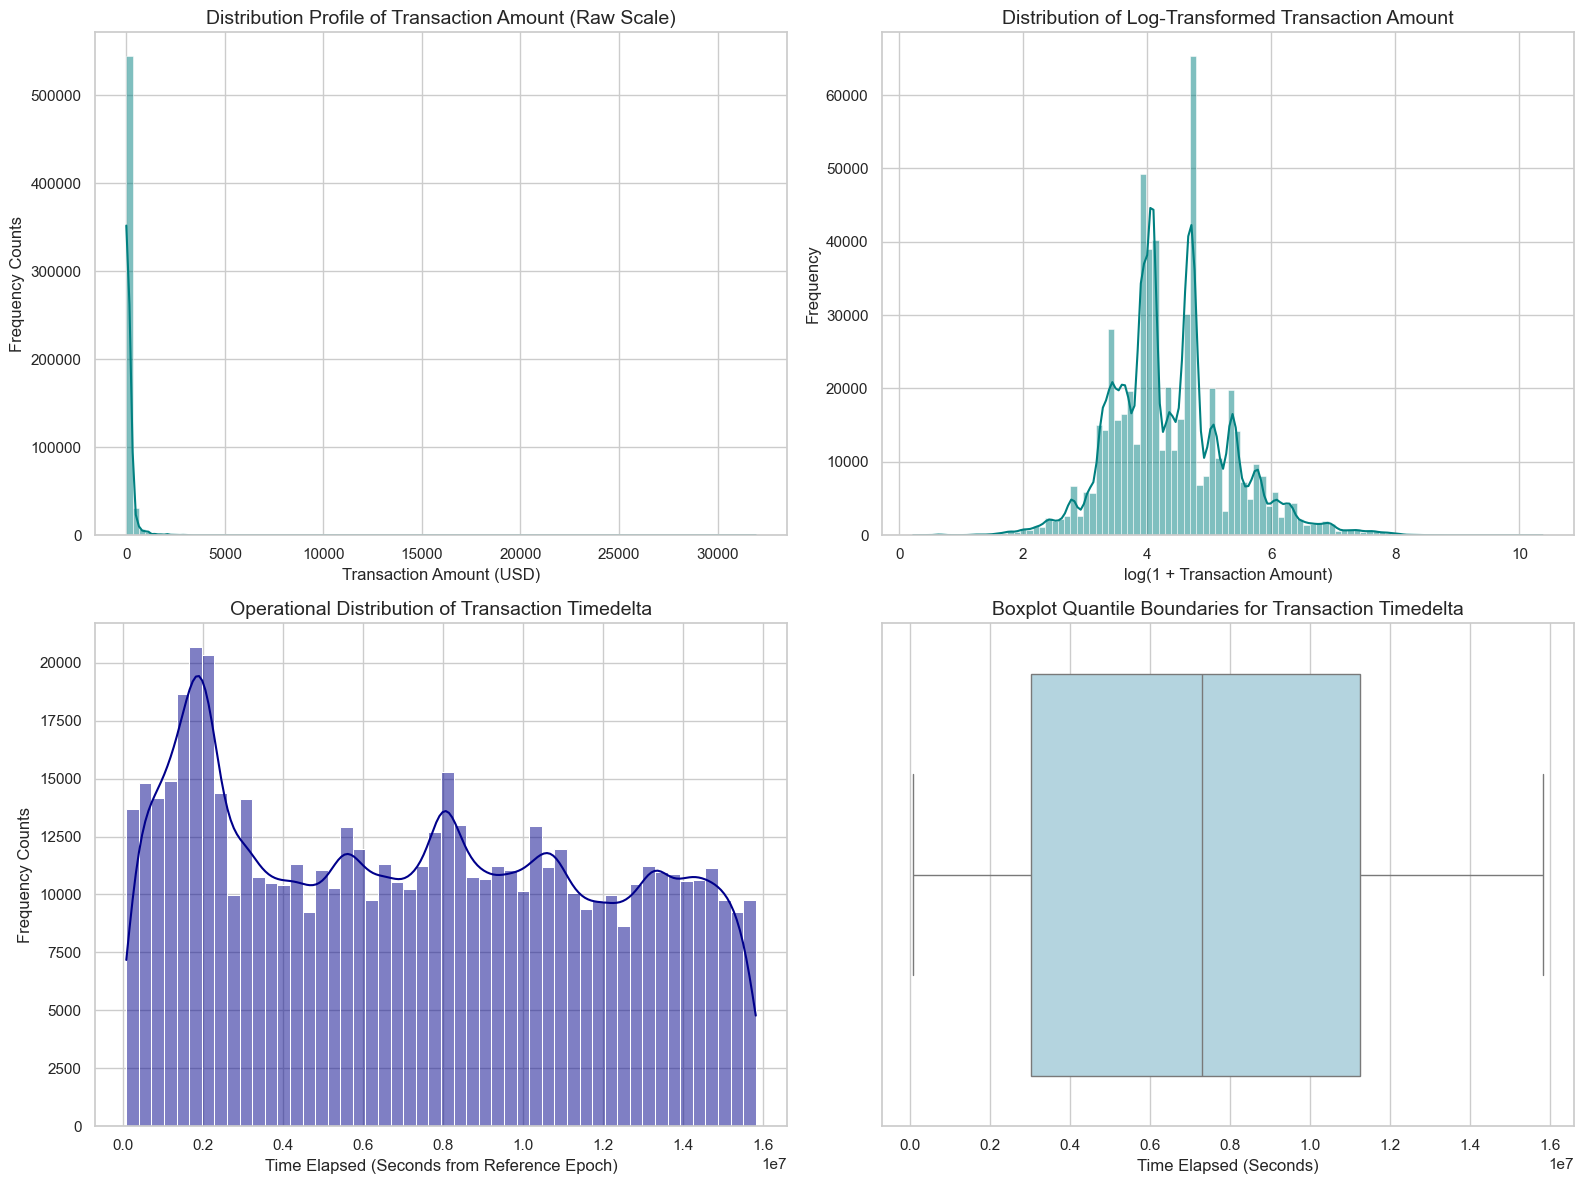

--- Quantitative Descriptives Summary Matrix ---
       TransactionAmt  TransactionDT
count   590540.000000   5.905400e+05
mean       135.027176   7.372311e+06
std        239.162522   4.617224e+06
min          0.251000   8.640000e+04
25%         43.321000   3.027058e+06
50%         68.769000   7.306528e+06
75%        125.000000   1.124662e+07
max      31937.391000   1.581113e+07


In [172]:
# Section D: Exploratory Data Analysis
# Subsection: D1 - Univariate Analysis: Numerical Features

# 1. Initialize a 2x2 subplot canvas for clean, side-by-side metric inspection
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Feature 1: TransactionAmt (Financial Metrics) ---
# Subplot A: Histogram with KDE to evaluate natural distribution profiles
sns.histplot(data=df_train, x='TransactionAmt', bins=100, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title("Distribution Profile of Transaction Amount (Raw Scale)")
axes[0, 0].set_xlabel("Transaction Amount (USD)")
axes[0, 0].set_ylabel("Frequency Counts")

# Subplot B: Logarithmic scale distribution to handle the massive dollar outliers cleanly
sns.histplot(np.log1p(df_train['TransactionAmt']), bins=100, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title("Distribution of Log-Transformed Transaction Amount")
axes[0, 1].set_xlabel("log(1 + Transaction Amount)")
axes[0, 1].set_ylabel("Frequency")


# --- Feature 2: TransactionDT (Temporal Track) ---
# Subplot C: Histogram mapping operational trends over the timedelta expanse
sns.histplot(data=df_train, x='TransactionDT', bins=50, kde=True, ax=axes[1, 0], color='darkblue')
axes[1, 0].set_title("Operational Distribution of Transaction Timedelta")
axes[1, 0].set_xlabel("Time Elapsed (Seconds from Reference Epoch)")
axes[1, 0].set_ylabel("Frequency Counts")

# Subplot D: Boxplot profiling to locate data collection gaps or anomalous processing bursts
sns.boxplot(data=df_train, x='TransactionDT', ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title("Boxplot Quantile Boundaries for Transaction Timedelta")
axes[1, 1].set_xlabel("Time Elapsed (Seconds)")

# 2. Optimize graphic layout parameters to completely prevent label overlap
plt.tight_layout()
plt.show()

# 3. Print quantitative descriptive summaries to back up visual findings
print("--- Quantitative Descriptives Summary Matrix ---")
print(df_train[['TransactionAmt', 'TransactionDT']].describe())

**Conclusion:**   
`TransactionAmt` has a strong right-skewed distribution with many small transactions and a few very large transactions. These large values should not be removed automatically because they may contain useful fraud information.

`TransactionDT` is more evenly distributed across the observation period. It can help identify time-based transaction patterns, but it should not be interpreted as an actual date.

#### dist1, C1 and C2

`dist1` is a distance-related variable, while `C1` and `C2` are behavioral count variables. These variables are highly right-skewed because most observations have low values, but a small number of records have very high values.

For this reason, log-transformed plots are useful to see the distribution more clearly.

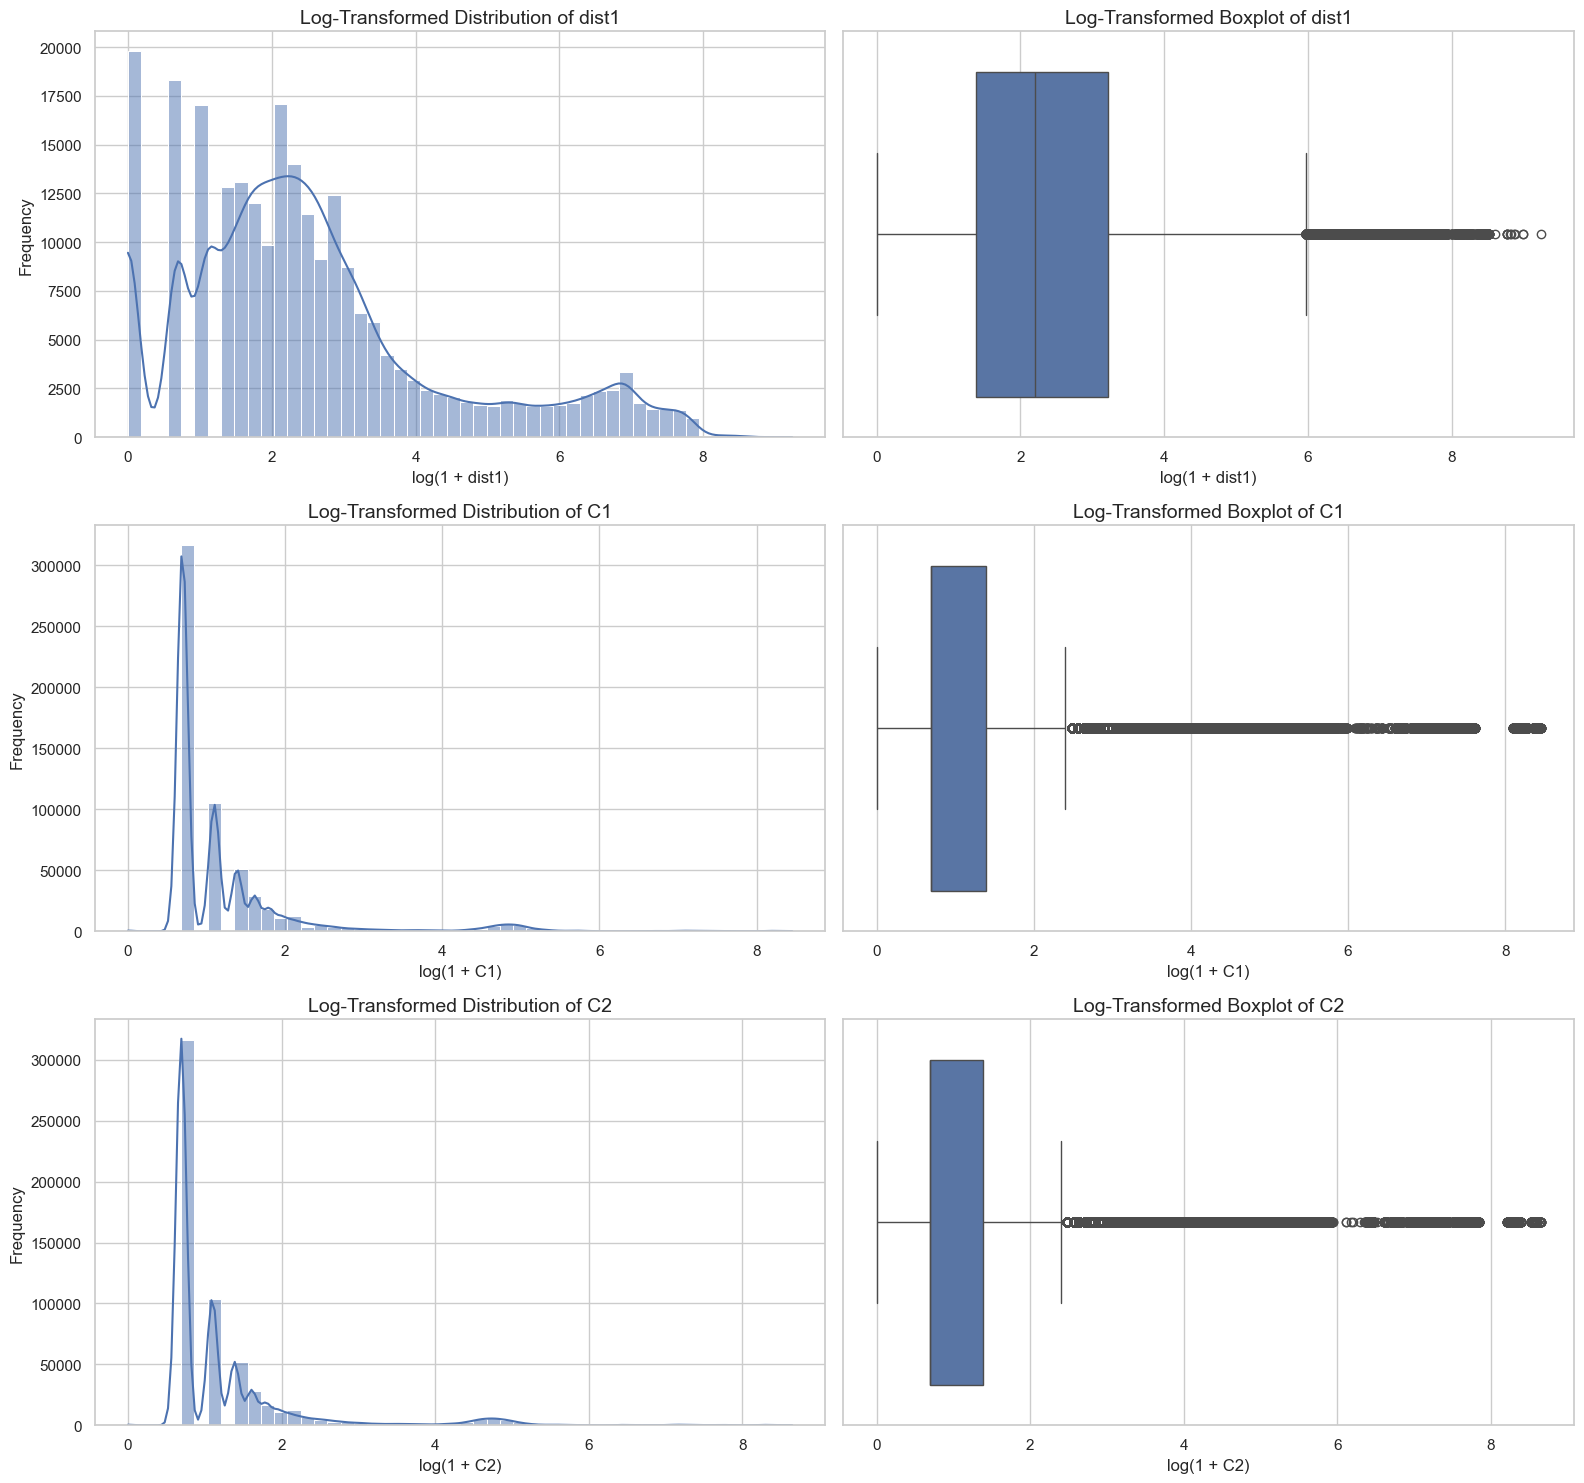

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent,skewness
dist1,238269.0,118.502180,371.872026,0.0,3.0,8.0,24.0,10286.0,352271,59.652352,5.108190
C1,590540.0,14.092458,133.569018,0.0,1.0,1.0,3.0,4685.0,0,0.000000,23.957960
C2,590540.0,15.269734,154.668899,0.0,1.0,1.0,3.0,5691.0,0,0.000000,23.677433


In [173]:
# Section D: Exploratory Data Analysis
# Subsection: D1 - Univariate Analysis: Numerical Features

# 1. Select numerical features
features = ['dist1', 'C1', 'C2']

# 2. Initialize a 3-row, 2-column dashboard layout
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 3. Create histograms and boxplots using log-transformed values
for i, feature in enumerate(features):
    
    # Drop missing values to avoid plotting errors
    feature_data = df_train[feature].dropna()
    
    # Apply log(1 + x) transformation
    log_feature_data = np.log1p(feature_data)
    
    # Histogram of log-transformed values
    sns.histplot(
        log_feature_data,
        bins=50,
        kde=True,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(f"Log-Transformed Distribution of {feature}")
    axes[i, 0].set_xlabel(f"log(1 + {feature})")
    axes[i, 0].set_ylabel("Frequency")
    
    # Boxplot of log-transformed values
    sns.boxplot(
        x=log_feature_data,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(f"Log-Transformed Boxplot of {feature}")
    axes[i, 1].set_xlabel(f"log(1 + {feature})")

# 4. Optimize layout
plt.tight_layout()
plt.show()

# 5. Output descriptive statistics to support the visual analysis
summary_d1 = df_train[features].describe().T

# Add missing values and skewness
summary_d1["missing_count"] = df_train[features].isna().sum()
summary_d1["missing_percent"] = df_train[features].isna().mean() * 100
summary_d1["skewness"] = df_train[features].skew()

display(summary_d1)

**Conclusion:**   
 `dist1`, `C1`, and `C2` show strong right-skewness and many extreme values. This means that most transactions have low values, while a small group of transactions has unusually high values.

These extreme values should be kept during EDA because they may represent important transaction behavior. For future modeling, log transformation, robust scaling, or tree-based models may be useful.

### D2 - Univariate Analysis: Categorical Features

I select a representative pool of core nominal features spanning all operational domains: Transaction attributes (ProductCD), Card characteristics (card4, card6), Verification flags (M4), and Device/Identity markers (DeviceType, id_12, id_15, id_38).

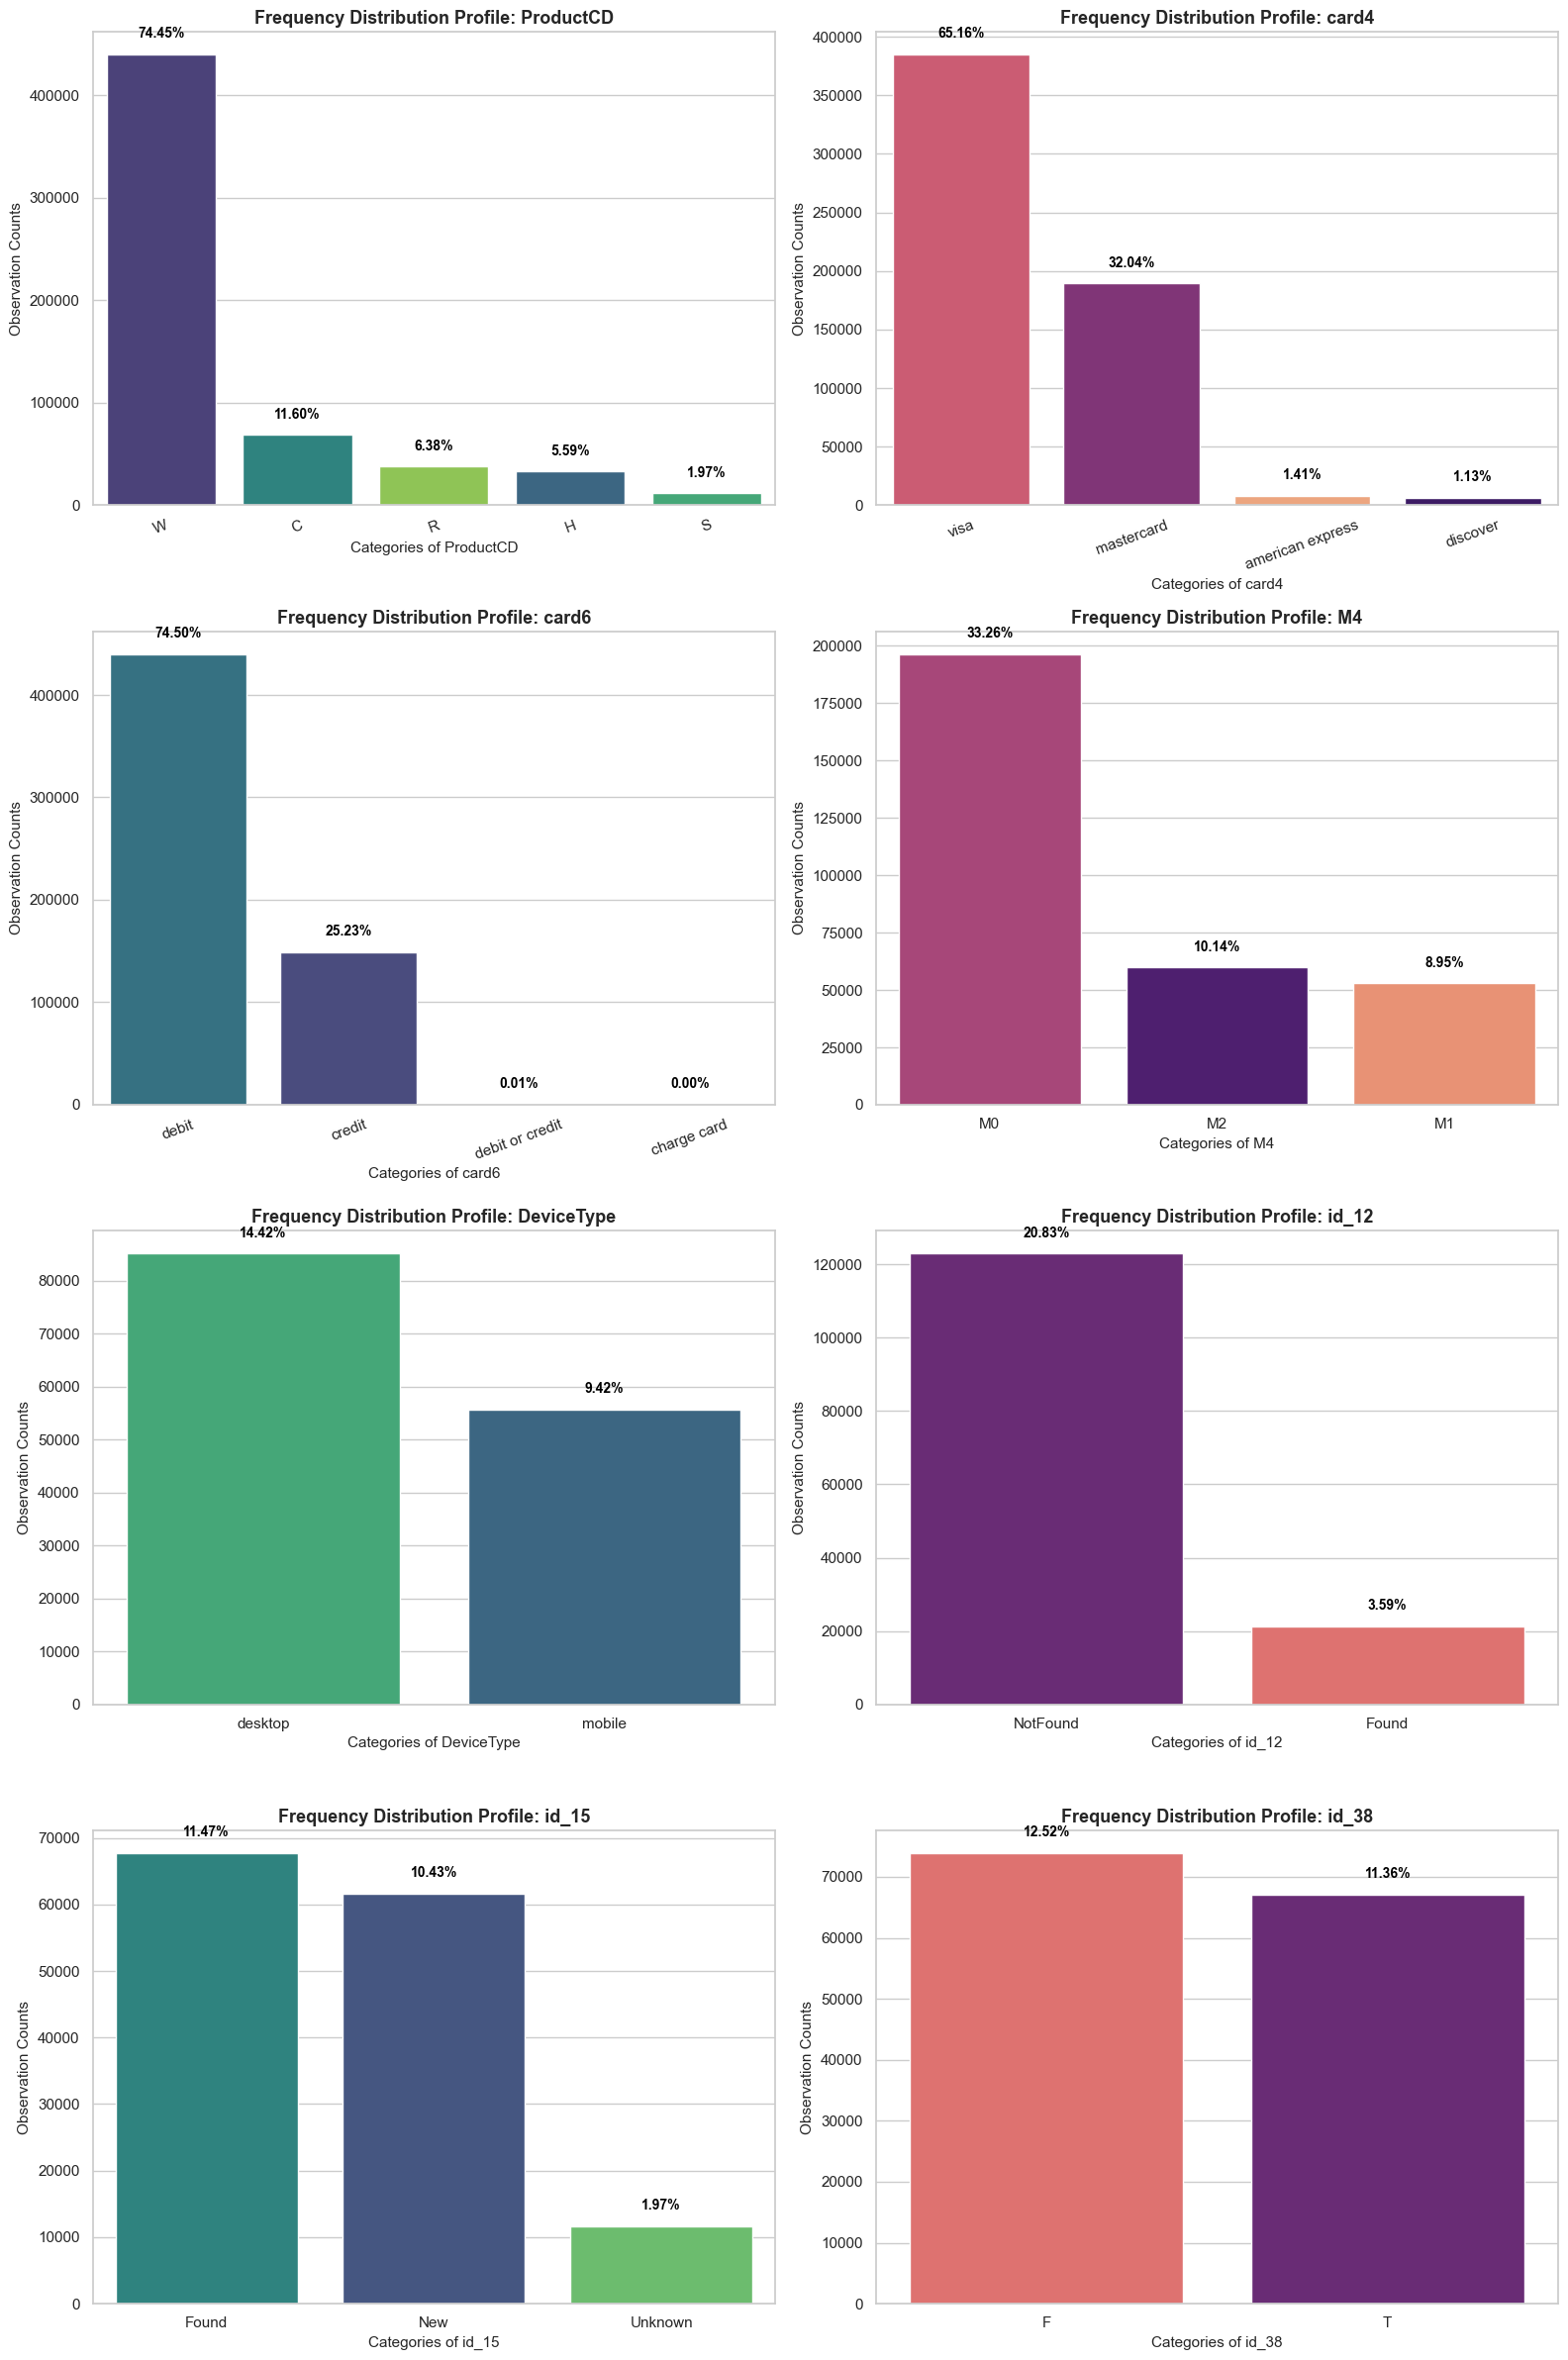

=== CATEGORICAL POOL DISTRIBUTION METRICS ===

Value Counts Summary for 'ProductCD':
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

Value Counts Summary for 'card4':
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

Value Counts Summary for 'card6':
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

Value Counts Summary for 'M4':
M4
NaN    281444
M0     196405
M2      59865
M1      52826
Name: count, dtype: int64

Value Counts Summary for 'DeviceType':
DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

Value Counts Summary for 'id_12':
id_12
NaN         446307
NotFound    123025
Found        21208
Name: count, dtype: int64

Value Counts Summary for 'id_15':
id_15
NaN    

In [174]:
from IPython.display import display, HTML

# Force Jupyter to completely disable output box scrolling via comprehensive CSS injection
# This targets standard Notebook, JupyterLab, and modern interface layout wrappers
disable_scroll_css = """
<style>
    .output_scroll, .output_wrapper, .jp-OutputArea-child, .jp-Cell-outputArea {
        height: auto !important;
        max-height: none !important;
        overflow: visible !important;
    }
</style>
"""
display(HTML(disable_scroll_css))

# Define the targeted baseline pool of representative categorical variables
categorical_pool = [
    'ProductCD', 'card4', 'card6', 'M4', 
    'DeviceType', 'id_12', 'id_15', 'id_38'
]

# Verify and extract features currently active within the working slice
active_categorical = [col for col in categorical_pool if col in df_train.columns]

# Compute dynamic structural subplot matrix boundaries
num_plots = len(active_categorical)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

# Configure a high-resolution vertical canvas (24 inches) to prevent visual compaction
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 6 * num_rows))
axes = axes.flatten()

total_observations = len(df_train)

# Construct the comprehensive univariate categorical visualization pipeline
for i, col in enumerate(active_categorical):
    ax = axes[i]
    
    # Sort categories in descending order to enforce intuitive Pareto layouts
    sorted_order = df_train[col].dropna().value_counts().index
    
    # Execute the counts visualization using modern hue assignments to avoid deprecation warnings
    sns.countplot(
        data=df_train,
        x=col,
        hue=col,
        order=sorted_order,
        ax=ax,
        palette='viridis' if i % 2 == 0 else 'magma',
        legend=False
    )
    
    # Apply executive typographic attributes and labels
    ax.set_title(f"Frequency Distribution Profile: {col}", fontsize=13, fontweight='bold')
    ax.set_xlabel(f"Categories of {col}", fontsize=11)
    ax.set_ylabel("Observation Counts", fontsize=11)
    
    # Calculate a proportional 3% visual offset based on maximum bin heights to prevent label clipping
    try:
        max_bar_height = df_train[col].value_counts().max()
        y_offset = max_bar_height * 0.03
    except:
        y_offset = 1000
        
    # Programmatically inject empirical percentage string flags above each valid patch
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            percentage_string = f'{100 * h / total_observations:.2f}%'
            ax.annotate(
                percentage_string, 
                (p.get_x() + p.get_width() / 2., h + y_offset), 
                ha='center', 
                va='bottom', 
                fontsize=10, 
                color='black', 
                fontweight='bold'
            )
            
    # Apply systematic horizontal label rotation for high-cardinality nominal vectors
    if len(sorted_order) > 3:
        ax.tick_params(axis='x', rotation=20)

# Purge empty structural subplots if the final active feature volume is odd
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Enforce strict padding boundaries to streamline downstream PDF exports
plt.tight_layout()
plt.show()

# Print comprehensive frequency dataframes to secure data tracking validation
print("=== CATEGORICAL POOL DISTRIBUTION METRICS ===")
for col in active_categorical:
    print(f"\nValue Counts Summary for '{col}':")
    print(df_train[col].value_counts(dropna=False))

**Conclusion:**  
The categorical variables are highly imbalanced. Some categories appear much more often than others, especially in variables such as `ProductCD`, `card4`, `card6`, and `DeviceType`.

This is important for feature selection because rare categories may still contain useful fraud information. These categorical variables should be kept for supervised analysis in **D3.2c** (fraud rates + Chi-square).

### D3 - Supervised univariate filters vs `isFraud`

#### D3.1 — Global overview: which features correlate with fraud vs legitimate?

Before testing individual variables (boxplots and statistical tests below), I rank **all features** by their Pearson (point-biserial) correlation with `isFraud`:

- **Positive correlation** → higher values tend to appear in **fraud** transactions
- **Negative correlation** → higher values tend to appear in **legitimate** transactions

With 400+ variables, a full pairplot is not readable. Instead I show two summary tables, one large signed bar chart, a heatmap among the top features, and a pairplot for only the top 5 predictors (subsampled for clarity).


In [175]:
# Build numeric matrix for correlation ranking (EDA only — not the final ML pipeline)
from IPython.display import display

CORR_SAMPLE = 80_000   # stratified subsample for speed
TOP_TABLE = 15
TOP_BAR = 30
TOP_HEATMAP = 12
TOP_PAIR = 5
PAIR_SAMPLE = 5_000

df_corr = df_train.copy()
if len(df_corr) > CORR_SAMPLE:
    df_corr = df_corr.groupby('isFraud', group_keys=False).apply(
        lambda g: g.sample(int(CORR_SAMPLE * len(g) / len(df_corr)), random_state=42)
    ).reset_index(drop=True)

y_corr = df_corr['isFraud'].astype(int)
X_corr = df_corr.drop(columns=['TransactionID', 'isFraud'], errors='ignore')

for col in X_corr.columns:
    if X_corr[col].dtype == 'object' or X_corr[col].dtype.name == 'category':
        X_corr[col] = X_corr[col].fillna('Missing').astype(str).astype('category').cat.codes
    else:
        X_corr[col] = X_corr[col].fillna(X_corr[col].median())

corr_with_fraud = X_corr.corrwith(y_corr).dropna().sort_values(ascending=False)
corr_abs = corr_with_fraud.abs().sort_values(ascending=False)

# Table 1 — fraud-associated (positive)
top_pos = corr_with_fraud.head(TOP_TABLE)
tbl_pos = pd.DataFrame({
    'Feature': top_pos.index,
    'Correlation_with_isFraud': top_pos.values.round(4),
    'Interpretation': 'Higher value → more likely FRAUD'
})

# Table 2 — legitimate-associated (negative)
top_neg = corr_with_fraud.tail(TOP_TABLE).sort_values()
tbl_neg = pd.DataFrame({
    'Feature': top_neg.index,
    'Correlation_with_isFraud': top_neg.values.round(4),
    'Interpretation': 'Higher value → more likely LEGITIMATE'
})

print('=' * 72)
print('TABLE 1 — Top features POSITIVELY correlated with FRAUD')
print('=' * 72)
display(tbl_pos.style.background_gradient(subset=['Correlation_with_isFraud'], cmap='Reds', vmin=0))

print('\n' + '=' * 72)
print('TABLE 2 — Top features NEGATIVELY correlated with FRAUD (legitimate-associated)')
print('=' * 72)
display(tbl_neg.style.background_gradient(subset=['Correlation_with_isFraud'], cmap='Blues_r', vmax=0))


TABLE 1 — Top features POSITIVELY correlated with FRAUD


,Feature,Correlation_with_isFraud,Interpretation
0,V257,0.278500,Higher value → more likely FRAUD
1,V246,0.257100,Higher value → more likely FRAUD
2,V244,0.255000,Higher value → more likely FRAUD
3,V242,0.252800,Higher value → more likely FRAUD
4,V201,0.241800,Higher value → more likely FRAUD
5,V200,0.233100,Higher value → more likely FRAUD
6,V45,0.229500,Higher value → more likely FRAUD
7,V189,0.218200,Higher value → more likely FRAUD
8,V86,0.214600,Higher value → more likely FRAUD
9,V188,0.209500,Higher value → more likely FRAUD



TABLE 2 — Top features NEGATIVELY correlated with FRAUD (legitimate-associated)


,Feature,Correlation_with_isFraud,Interpretation
0,ProductCD,-0.154400,Higher value → more likely LEGITIMATE
1,DeviceType_Missing,-0.130900,Higher value → more likely LEGITIMATE
2,id_36,-0.126900,Higher value → more likely LEGITIMATE
3,id_01,-0.119100,Higher value → more likely LEGITIMATE
4,V69,-0.102700,Higher value → more likely LEGITIMATE
5,V29,-0.102500,Higher value → more likely LEGITIMATE
6,V90,-0.102100,Higher value → more likely LEGITIMATE
7,V70,-0.098700,Higher value → more likely LEGITIMATE
8,V30,-0.098400,Higher value → more likely LEGITIMATE
9,V91,-0.097300,Higher value → more likely LEGITIMATE


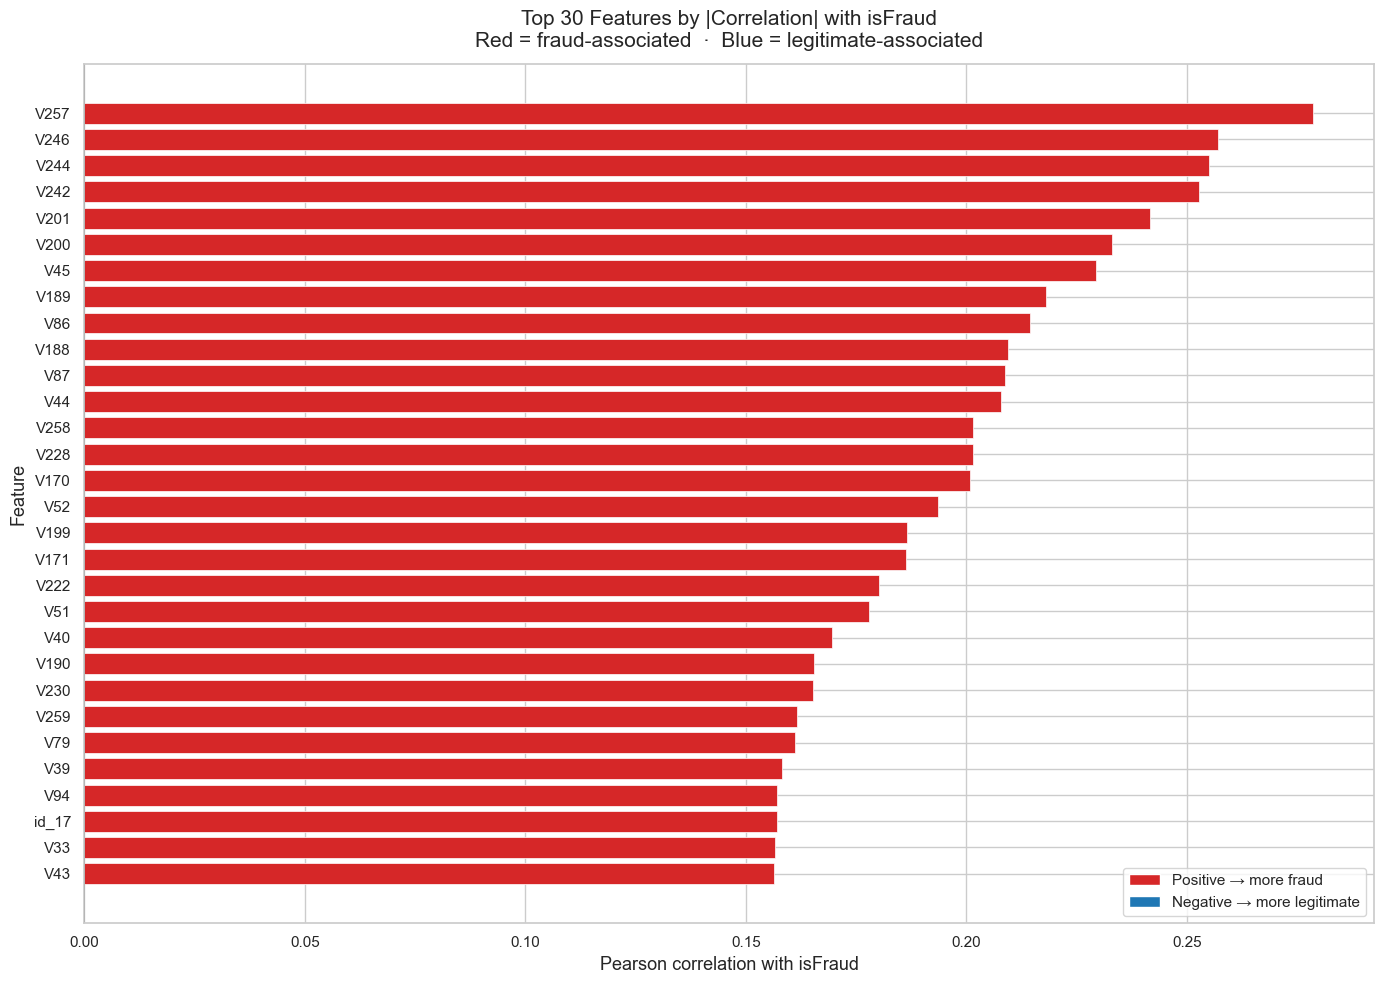

In [176]:
# Large signed bar chart — top |correlation| features
top_bar_feats = corr_abs.head(TOP_BAR).index
bar_vals = corr_with_fraud.loc[top_bar_feats].sort_values()
colors = ['#d62728' if v > 0 else '#1f77b4' for v in bar_vals]

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(bar_vals.index, bar_vals.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Pearson correlation with isFraud', fontsize=13)
ax.set_ylabel('Feature', fontsize=13)
ax.set_title(
    f'Top {TOP_BAR} Features by |Correlation| with isFraud\n'
    'Red = fraud-associated  ·  Blue = legitimate-associated',
    fontsize=15, pad=12
)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#d62728', label='Positive → more fraud'),
    Patch(facecolor='#1f77b4', label='Negative → more legitimate'),
], loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


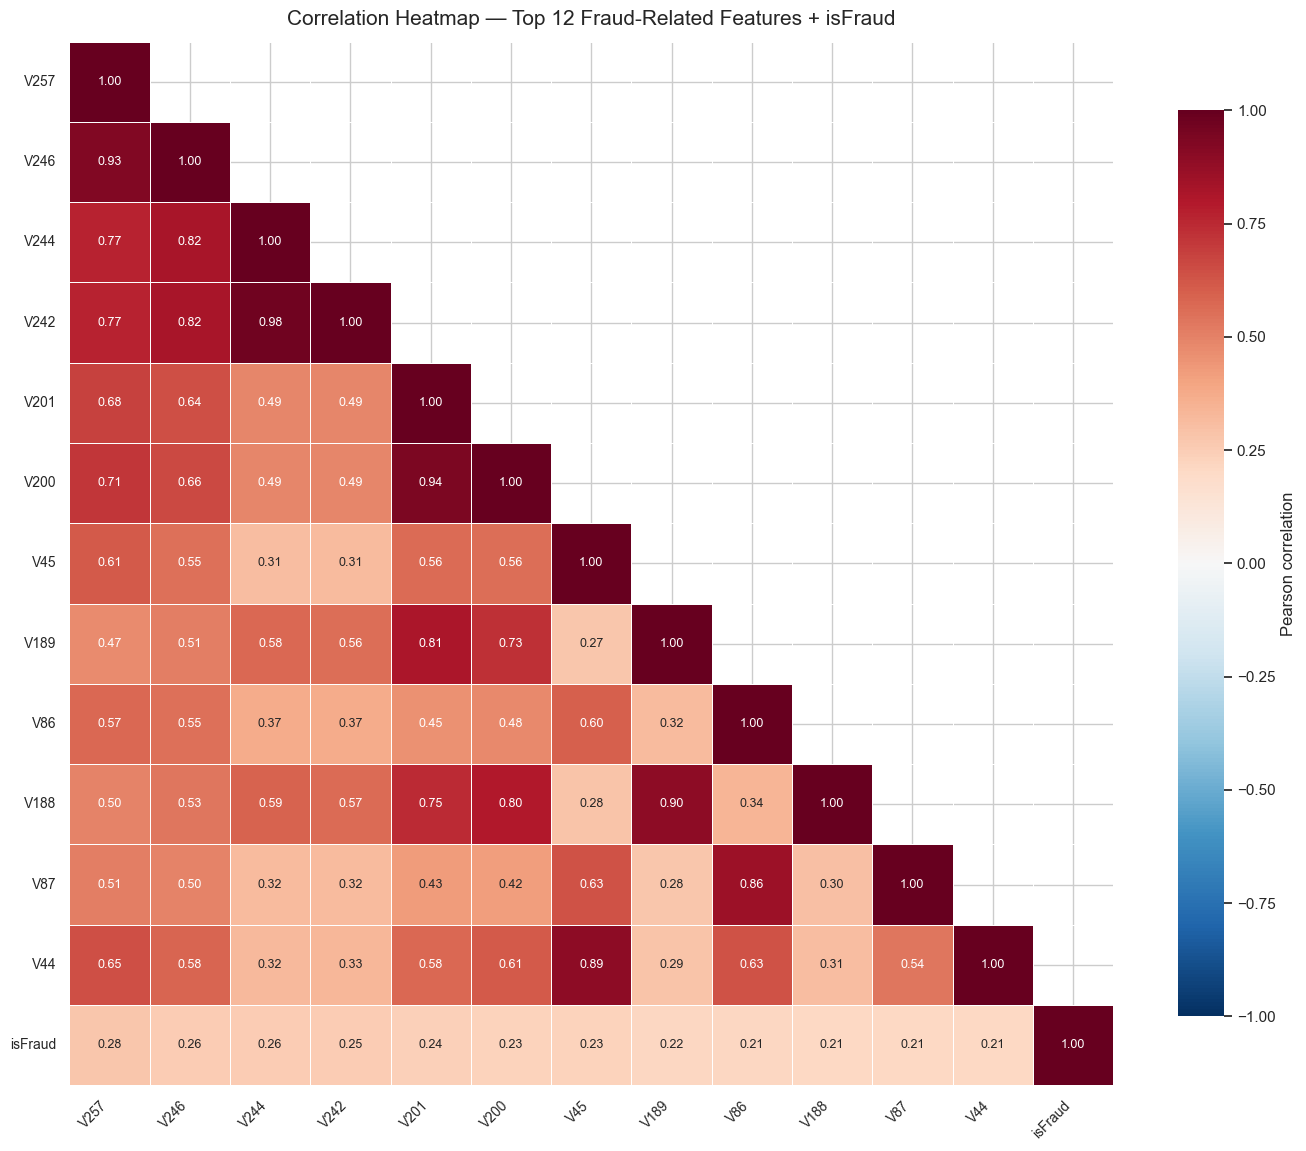

In [177]:
# Heatmap — correlations among top features + isFraud
heat_feats = corr_abs.head(TOP_HEATMAP).index.tolist()
heat_df = X_corr[heat_feats].copy()
heat_df['isFraud'] = y_corr.values
heat_corr = heat_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(heat_corr, dtype=bool), k=1)
sns.heatmap(
    heat_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax,
    cbar_kws={'label': 'Pearson correlation', 'shrink': 0.8}
)
ax.set_title(
    f'Correlation Heatmap — Top {TOP_HEATMAP} Fraud-Related Features + isFraud',
    fontsize=15, pad=12
)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


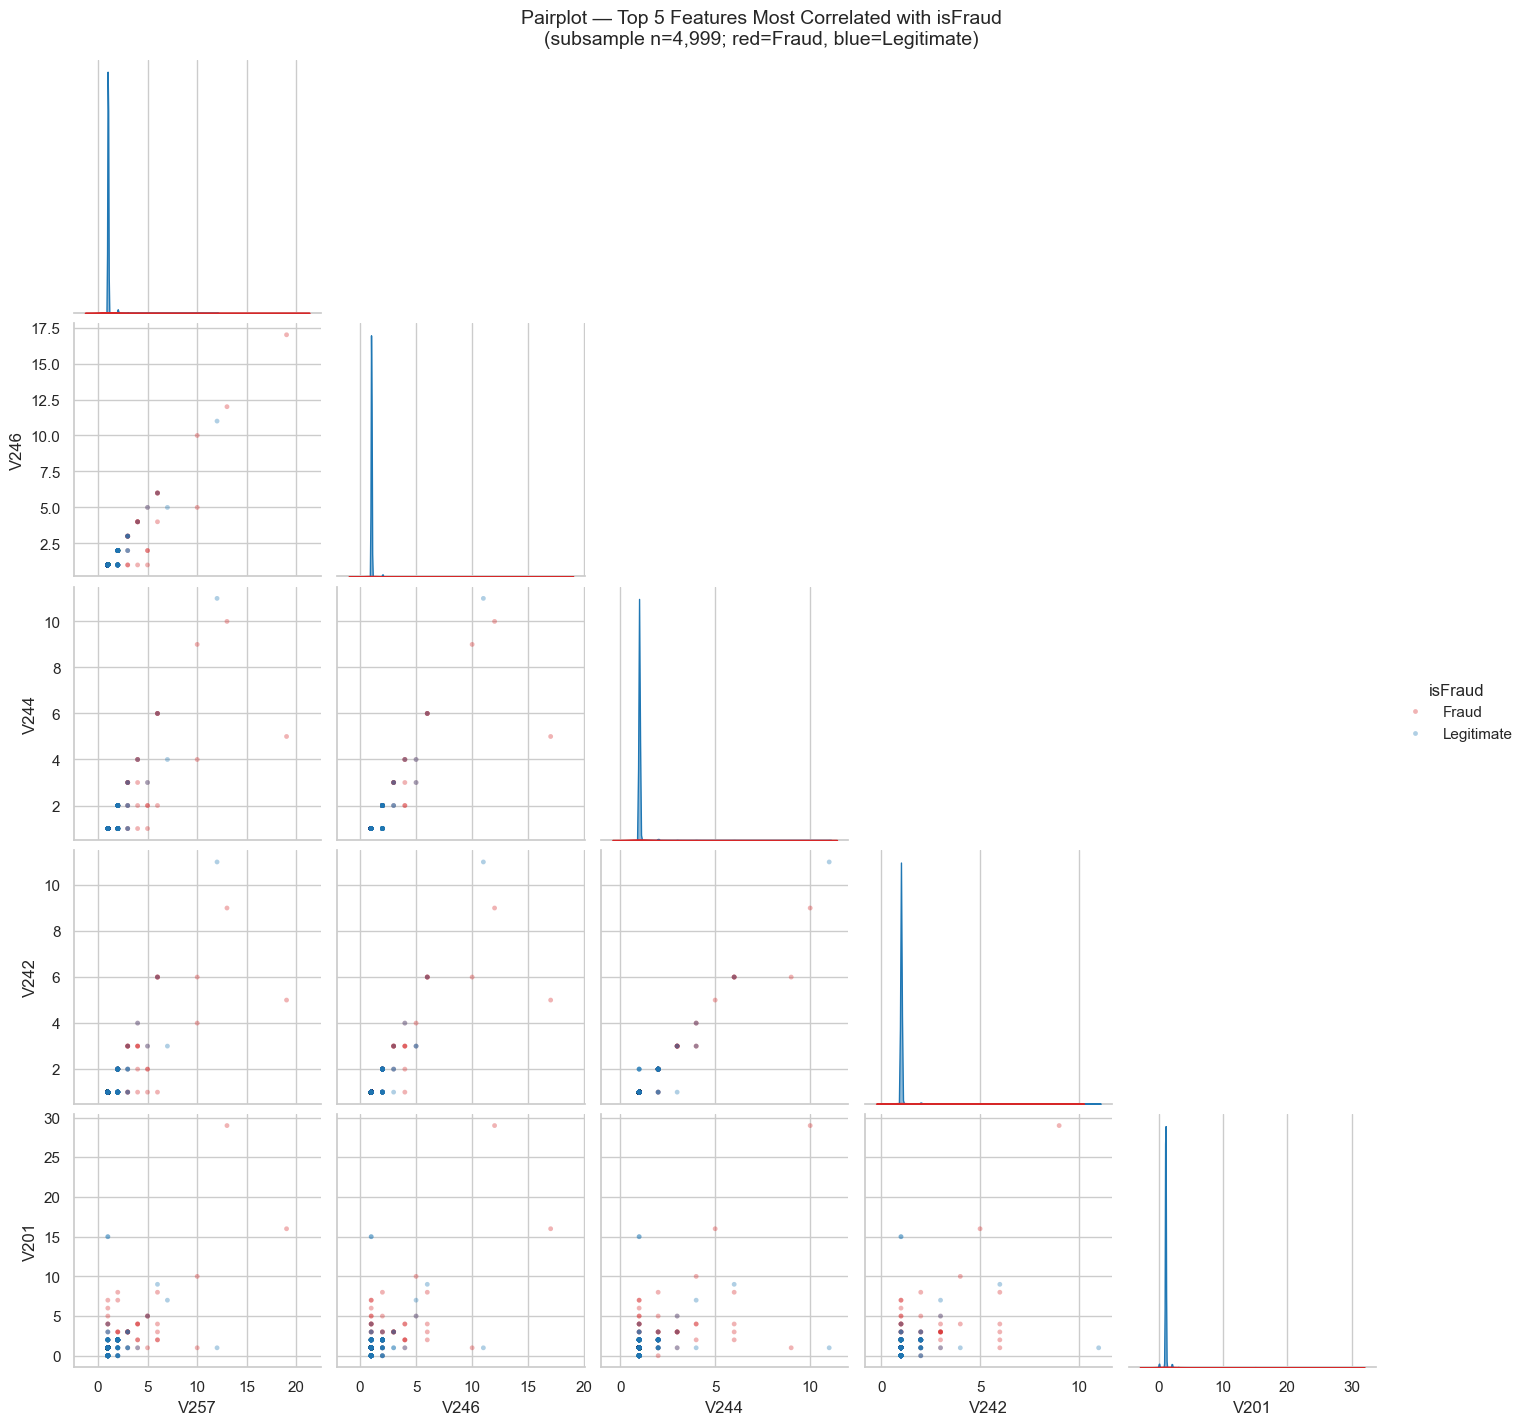

In [178]:
# Pairplot — top 5 features coloured by fraud vs legitimate
pair_feats = corr_abs.head(TOP_PAIR).index.tolist()
pair_df = X_corr[pair_feats].copy()
pair_df['isFraud'] = y_corr.map({0: 'Legitimate', 1: 'Fraud'})

if len(pair_df) > PAIR_SAMPLE:
    pair_df = pair_df.groupby('isFraud', group_keys=False).apply(
        lambda g: g.sample(int(PAIR_SAMPLE * len(g) / len(pair_df)), random_state=42)
    ).reset_index(drop=True)

g = sns.pairplot(
    pair_df, hue='isFraud', palette={'Legitimate': '#1f77b4', 'Fraud': '#d62728'},
    diag_kind='kde', corner=True,
    plot_kws={'alpha': 0.35, 's': 12, 'linewidth': 0},
    diag_kws={'fill': True, 'alpha': 0.5}, height=2.8
)
g.fig.suptitle(
    f'Pairplot — Top {TOP_PAIR} Features Most Correlated with isFraud\n'
    f'(subsample n={len(pair_df):,}; red=Fraud, blue=Legitimate)',
    y=1.02, fontsize=14
)
plt.show()


**Initial reading:** Several **V-features** (e.g. V257, V244, V242) show the strongest positive Pearson association with fraud. Some **label-encoded** identity indicators (e.g. `id_36`) show negative association — more common among legitimate transactions. `ProductCD` is categorical; its fraud signal is assessed via fraud-rate and Chi-square in **D3.2c**, not raw Pearson.

The heatmap below also shows **strong redundancy** among top-ranked variables (e.g. V257–V246, V244–V242, V201–V200 with pairwise |r| > 0.90). These features are relevant to fraud but overlap in information — multivariate feature selection (A2 CFS/CON) is needed to choose a non-redundant subset.

These rankings guide the detailed tests in **D3.2** below and the feature-selection work in Assignment 2.


#### D3.2 — Detailed tests: feature vs `isFraud`

We first examine the strongest signals from D3.1 (D3.2a), then a wider set of variables (D3.2b numerics, D3.2c categoricals).


**Which plot for which variable type?**

| Variable type | Recommended plot | Why |
|---------------|------------------|-----|
| **Numeric** (V257, V244, V242, TransactionAmt…) | **Boxplot** (or violin) by `isFraud` | Compare distribution / median / spread between fraud vs legitimate |
| **Categorical** (ProductCD, card4…) | **Bar chart** of fraud rate by category | Categories have no order; boxplots would be misleading |
| **Binary flag** (DeviceType missing yes/no) | **Bar chart** of proportion or fraud rate | Only two levels — not a numeric scale |

So: **boxplots for numerics is correct.** For **DeviceType absence** we use a bar chart + Chi-square (already introduced in Section C).


#### D3.2a — Top fraud signals from D3.1 correlation ranking

Following D3.1, I inspect the three V-features with the strongest positive correlation with fraud, plus **DeviceType missingness** (identity not captured — linked to fraud in Section C).


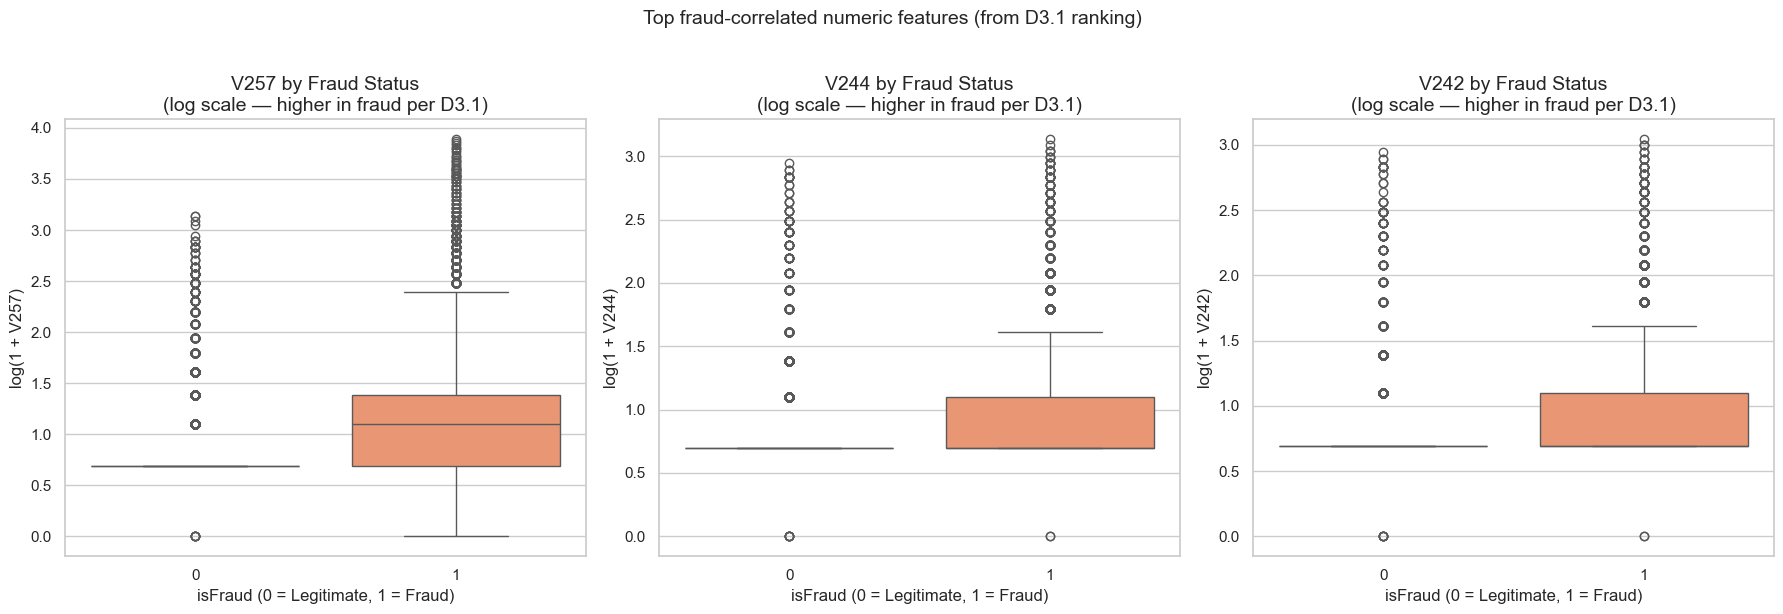

,feature,test,statistic,p_value,significant_at_0.05
0,V257,Mann-Whitney U,333435194.0,0.0,True
1,V244,Mann-Whitney U,393066890.5,0.0,True
2,V242,Mann-Whitney U,398652536.5,0.0,True


In [179]:
# --- Numeric: V257, V244, V242 (top positive correlation with isFraud in D3.1) ---
top_fraud_numeric = ['V257', 'V244', 'V242']
top_fraud_numeric = [c for c in top_fraud_numeric if c in df_train.columns]

fig, axes = plt.subplots(1, len(top_fraud_numeric), figsize=(6 * len(top_fraud_numeric), 6))
if len(top_fraud_numeric) == 1:
    axes = [axes]

for ax, col in zip(axes, top_fraud_numeric):
    plot_data = df_train[[col, 'isFraud']].dropna().copy()
    plot_data[f'log_{col}'] = np.log1p(plot_data[col].clip(lower=0))
    sns.boxplot(data=plot_data, x='isFraud', y=f'log_{col}', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Fraud Status\n(log scale — higher in fraud per D3.1)')
    ax.set_xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
    ax.set_ylabel(f'log(1 + {col})')

plt.suptitle('Top fraud-correlated numeric features (from D3.1 ranking)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Mann-Whitney U tests
v_test_results = []
for col in top_fraud_numeric:
    g0 = df_train.loc[df_train['isFraud'] == 0, col].dropna()
    g1 = df_train.loc[df_train['isFraud'] == 1, col].dropna()
    stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    v_test_results.append({
        'feature': col, 'test': 'Mann-Whitney U',
        'statistic': stat, 'p_value': p_val,
        'significant_at_0.05': p_val < 0.05
    })
display(pd.DataFrame(v_test_results))


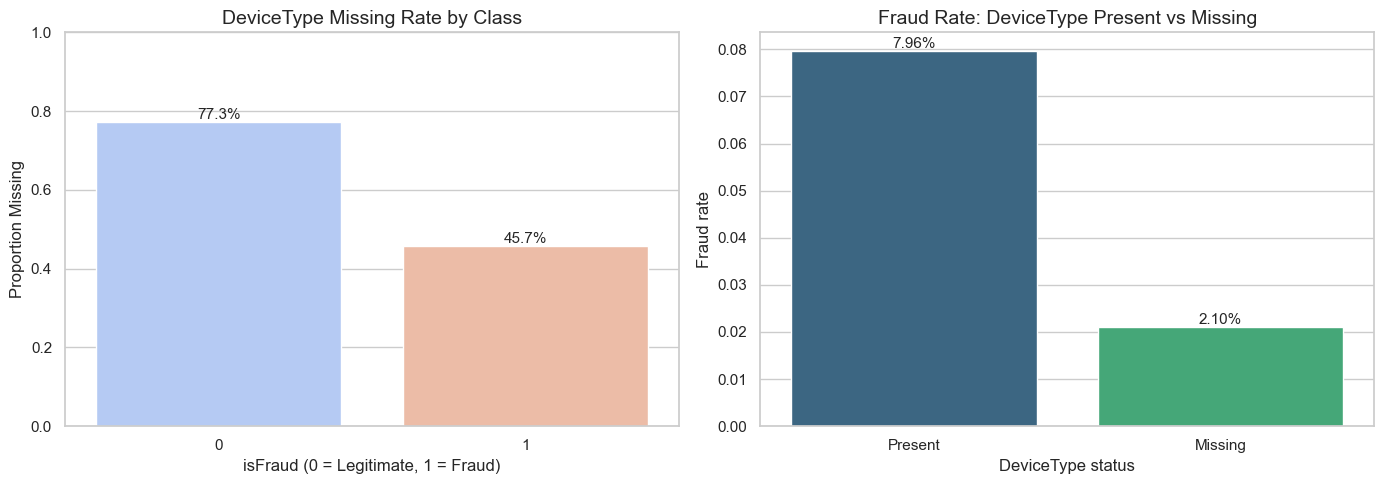

Contingency table (DeviceType_Missing × isFraud):


isFraud,0,1
DeviceType_Missing,,
False,129599,11211
True,440278,9452


Chi-square statistic: 10904.3351  |  p-value: 0.0000e+00


In [180]:
# --- Binary: DeviceType missing vs isFraud (NOT a boxplot — bar charts) ---
if 'DeviceType_Missing' not in df_train.columns:
    df_train['DeviceType_Missing'] = df_train['DeviceType'].isna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: missing rate by fraud class
miss_by_fraud = df_train.groupby('isFraud')['DeviceType_Missing'].mean().reset_index()
sns.barplot(data=miss_by_fraud, x='isFraud', y='DeviceType_Missing', ax=axes[0],
            palette='coolwarm', hue='isFraud', legend=False)
axes[0].set_title('DeviceType Missing Rate by Class')
axes[0].set_xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
axes[0].set_ylabel('Proportion Missing')
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f'{100 * p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Plot B: fraud rate when DeviceType present vs missing
fraud_by_miss = df_train.groupby('DeviceType_Missing')['isFraud'].mean().reset_index()
fraud_by_miss['DeviceType_Missing'] = fraud_by_miss['DeviceType_Missing'].map(
    {False: 'Present', True: 'Missing'})
sns.barplot(data=fraud_by_miss, x='DeviceType_Missing', y='isFraud', ax=axes[1],
            palette='viridis', hue='DeviceType_Missing', legend=False)
axes[1].set_title('Fraud Rate: DeviceType Present vs Missing')
axes[1].set_xlabel('DeviceType status')
axes[1].set_ylabel('Fraud rate')
for p in axes[1].patches:
    axes[1].annotate(f'{100 * p.get_height():.2f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Chi-square: missingness vs isFraud
dev_tab = pd.crosstab(df_train['DeviceType_Missing'], df_train['isFraud'])
chi2_stat, chi2_p, dof, _ = stats.chi2_contingency(dev_tab)
print('Contingency table (DeviceType_Missing × isFraud):')
display(dev_tab)
print(f'Chi-square statistic: {chi2_stat:.4f}  |  p-value: {chi2_p:.4e}')


**D3.2a conclusion:** `V257`, `V244`, and `V242` show higher values for fraud transactions (consistent with D3.1). Mann–Whitney U tests indicate statistically significant distributional differences (p < 0.001). Because several top V-features are strongly correlated (D3.1 heatmap), feature selection should not rely on individual Pearson rankings alone. **DeviceType missingness** is more common among fraud and carries a higher fraud rate when missing — a **categorical/binary** pattern, so bar charts (not boxplots) are the right visualization.

---


#### D3.2b — Additional selected features (TransactionAmt, dist1, C1, C2)

Broader set of variables from the original EDA (not only the D3.1 top rank).


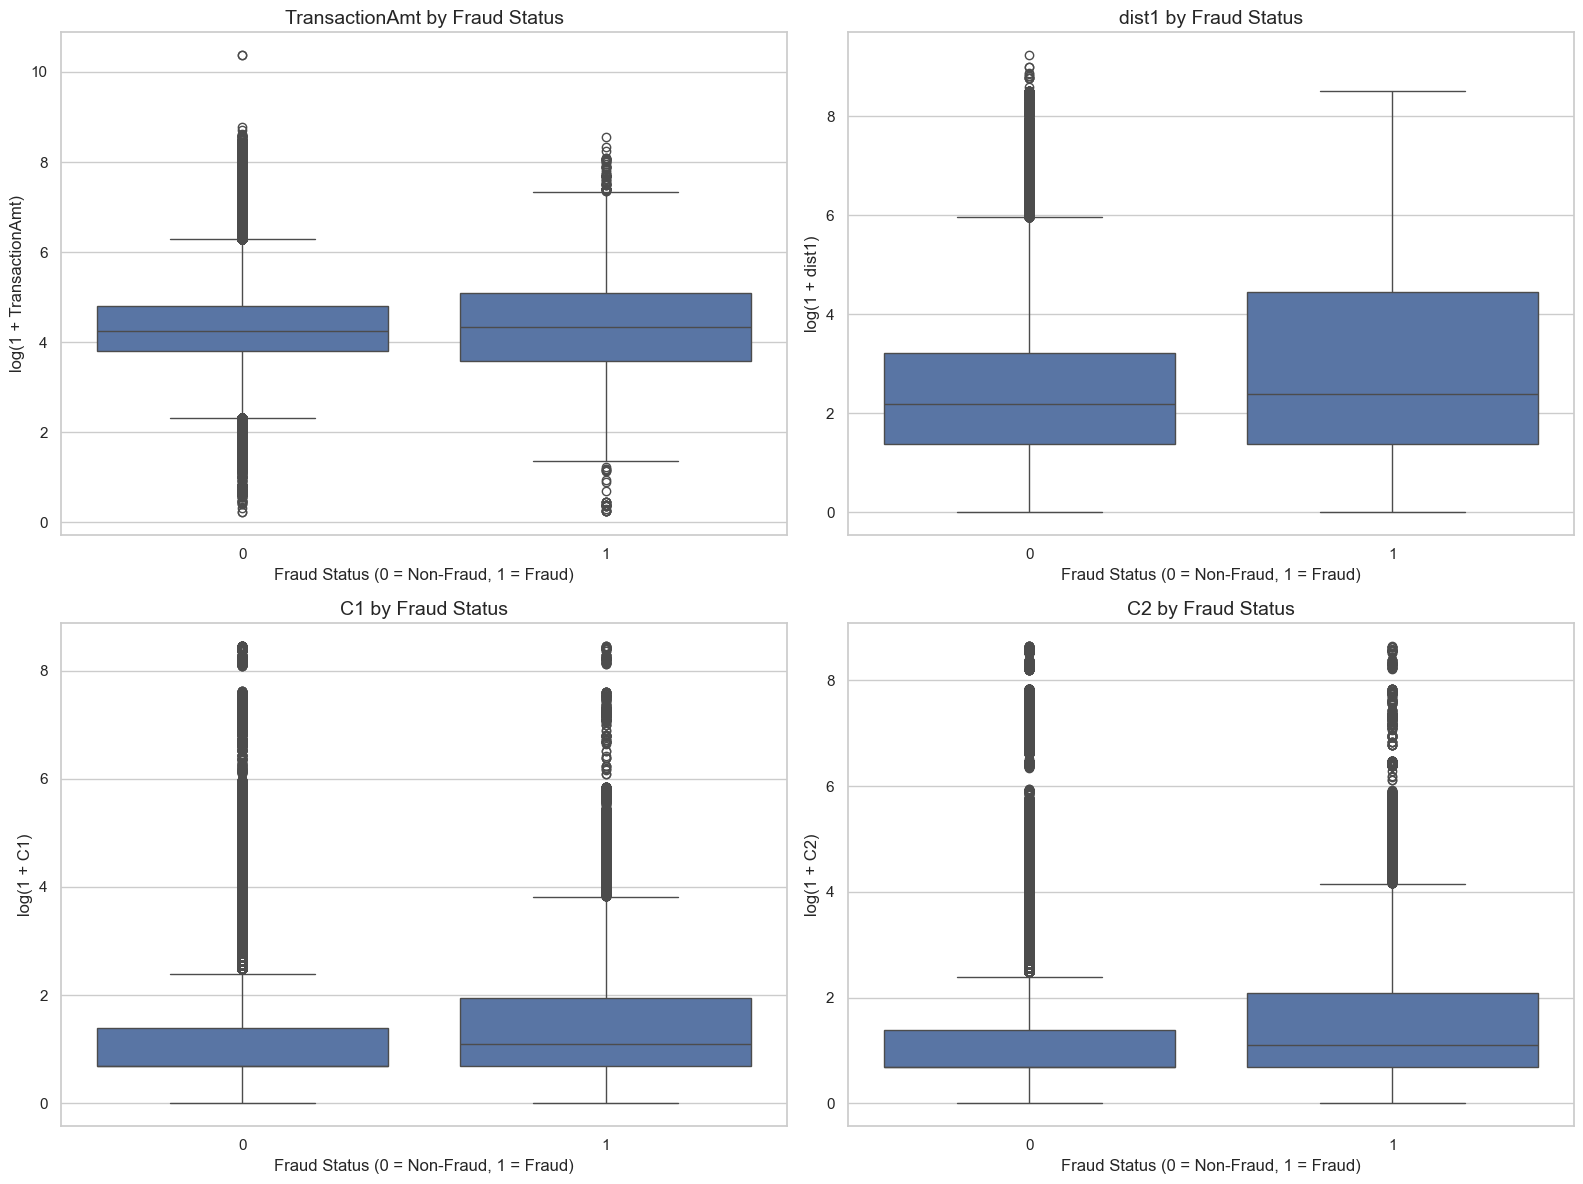

,feature,test,statistic,p_value,significant_at_0.05
0,TransactionAmt,Mann-Whitney U,5.916828e+09,2.259078e-01,False
1,dist1,Mann-Whitney U,5.075719e+08,3.317800e-24,True
2,C1,Mann-Whitney U,4.555828e+09,0.000000e+00,True
3,C2,Mann-Whitney U,4.370063e+09,0.000000e+00,True


In [181]:
# -----------------------------
# 1. Numerical features vs target
# -----------------------------

numerical_target_features = [
    'TransactionAmt',
    'dist1',
    'C1',
    'C2'
]

numerical_target_features = [
    col for col in numerical_target_features 
    if col in df_train.columns
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_target_features):
    plot_data = df_train[[col, 'isFraud']].dropna().copy()
    plot_data[f'log_{col}'] = np.log1p(plot_data[col])
    
    sns.boxplot(
        data=plot_data,
        x='isFraud',
        y=f'log_{col}',
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} by Fraud Status")
    axes[i].set_xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
    axes[i].set_ylabel(f"log(1 + {col})")

plt.tight_layout()
plt.show()


# Mann-Whitney U tests for numerical variables
numerical_test_results = []

for col in numerical_target_features:
    group_0 = df_train.loc[df_train['isFraud'] == 0, col].dropna()
    group_1 = df_train.loc[df_train['isFraud'] == 1, col].dropna()
    
    stat, p_value = stats.mannwhitneyu(
        group_0,
        group_1,
        alternative='two-sided'
    )
    
    numerical_test_results.append({
        'feature': col,
        'test': 'Mann-Whitney U',
        'statistic': stat,
        'p_value': p_value,
        'significant_at_0.05': p_value < 0.05
    })

numerical_test_results = pd.DataFrame(numerical_test_results)
display(numerical_test_results)

**Numerical variables conclusion:**  
`TransactionAmt` does not show a strong difference between fraud and non-fraud transactions. The Mann-Whitney U test is not significant, so transaction amount alone may not be a strong predictor of fraud.

`dist1`, `C1`, and `C2` show statistically significant differences between fraud and non-fraud transactions. In the boxplots, fraud transactions tend to have slightly higher values, especially for `C1` and `C2`.

This suggests that behavioral count variables such as `C1` and `C2` may be more useful for fraud prediction than transaction amount alone.

#### D3.2c — Categorical features vs isFraud

Fraud rate by category and Chi-square tests for `ProductCD`, `card4`, `card6`, and `DeviceType`.


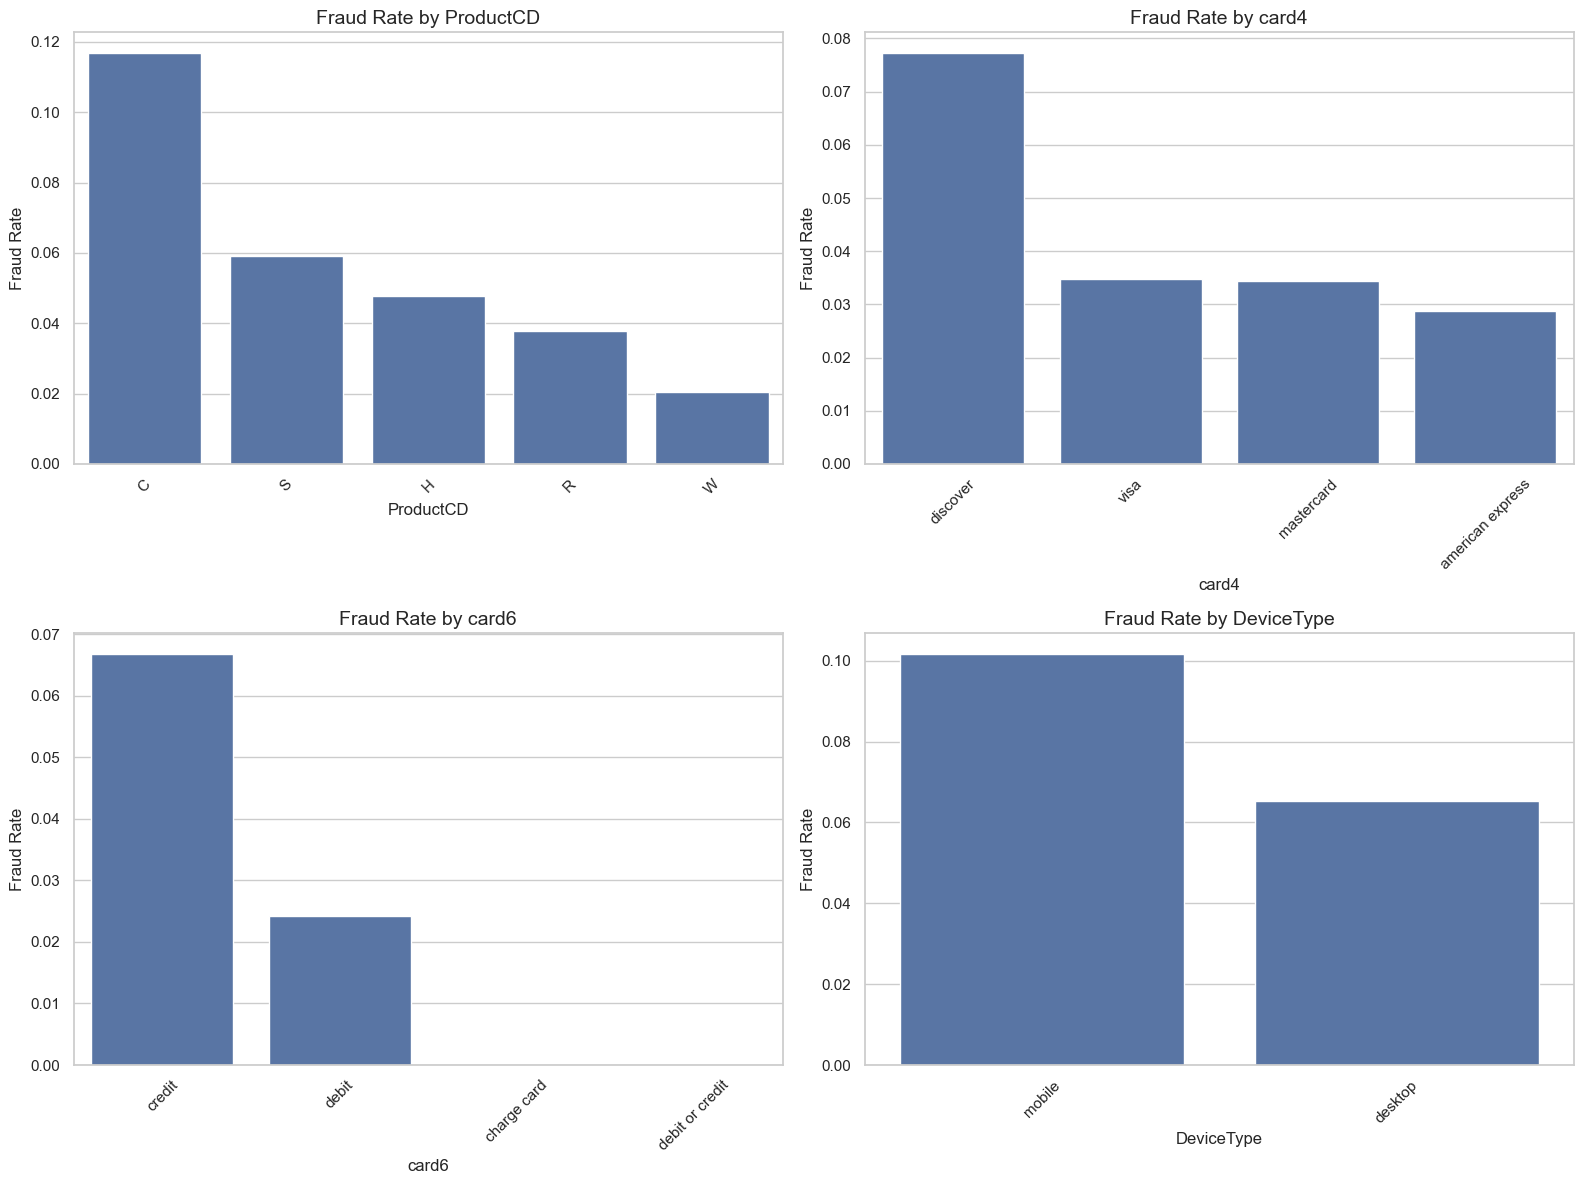

,feature,test,statistic,p_value,degrees_of_freedom,significant_at_0.05
0,ProductCD,Chi-square,16742.171529,0.000000e+00,4,True
1,card4,Chi-square,364.874139,8.969834e-79,3,True
2,card6,Chi-square,5957.032292,0.000000e+00,3,True
3,DeviceType,Chi-square,609.623764,1.350769e-134,1,True


In [182]:
# -----------------------------
# 2. Categorical features vs target
# -----------------------------

categorical_target_features = [
    'ProductCD',
    'card4',
    'card6',
    'DeviceType'
]

categorical_target_features = [
    col for col in categorical_target_features 
    if col in df_train.columns
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_target_features):
    fraud_rate = (
        df_train
        .groupby(col)['isFraud']
        .mean()
        .reset_index()
        .sort_values(by='isFraud', ascending=False)
    )
    
    sns.barplot(
        data=fraud_rate,
        x=col,
        y='isFraud',
        ax=axes[i]
    )
    
    axes[i].set_title(f"Fraud Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fraud Rate")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Chi-square tests for categorical variables
categorical_test_results = []

for col in categorical_target_features:
    contingency_table = pd.crosstab(df_train[col], df_train['isFraud'])
    
    chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    
    categorical_test_results.append({
        'feature': col,
        'test': 'Chi-square',
        'statistic': chi2_stat,
        'p_value': chi2_p,
        'degrees_of_freedom': dof,
        'significant_at_0.05': chi2_p < 0.05
    })

categorical_test_results = pd.DataFrame(categorical_test_results)
display(categorical_test_results)

**Categorical variables conclusion:**  
The categorical variables show clear differences in fraud rate across categories. The Chi-square tests are significant for `ProductCD`, `card4`, `card6`, and `DeviceType`, which means these variables are related to the target variable `isFraud`.

`ProductCD` shows that category `C` has the highest fraud rate, while category `W` has the lowest fraud rate. For `card4`, Discover has a higher fraud rate than Visa, Mastercard, and American Express. For `card6`, credit cards show a higher fraud rate than debit cards.

`DeviceType` also shows a difference, with mobile transactions having a higher fraud rate than desktop transactions. These results suggest that categorical features can provide useful information for fraud prediction.

### D4 — Information & uncertainty

Following Zouhri, Idri & Ratnani (2024), this section adds an **information-theoretic** view of the data. Linear correlation (D3.1) measures monotonic association; **entropy** and **mutual information (MI)** measure uncertainty and how much knowing `isFraud` reduces uncertainty about each feature.

| Method | What it measures | Supervised? |
|--------|------------------|-------------|
| **Variance** | Spread of X alone | No |
| **Pearson (D3.1)** | Linear association X ↔ Y | Yes |
| **Entropy H(X)** | Uncertainty / disorder in X | No |
| **Mutual Information I(X;Y)** | Reduction in entropy of X when Y is known (paper §c) | Yes |
| **ReliefF (paper §d)** | Nearest-neighbour attribute quality (hit vs miss) | Yes |

> **Mutual Information (paper §c):** MI calculates the decrease in entropy of a feature under the condition of the target value. A high MI denotes a significant reduction in uncertainty when we consider the feature and the target at once — indicating strong dependence.

> **ReliefF (paper §d):** ReliefF measures attribute quality by how well it distinguishes instances that are close to one another. A relevant attribute has the **same value** for the nearest **hit** (same class) and a **different value** for the nearest **miss** (other class).

Full filter evaluation with Logistic Regression + CV is in **Assignment 2**; here we explore rankings on a stratified subsample.


In [183]:
# -- Build modelling matrix (same logic as D3.1) ──
from scipy.stats import entropy
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import mutual_info_classif

INFO_SAMPLE = 80_000
TOP_N = 20

df_info = df_train.copy()
if len(df_info) > INFO_SAMPLE:
    df_info = df_info.groupby('isFraud', group_keys=False).apply(
        lambda g: g.sample(int(INFO_SAMPLE * len(g) / len(df_info)), random_state=42)
    ).reset_index(drop=True)

y_info = df_info['isFraud'].astype(int)
X_info = df_info.drop(columns=['TransactionID', 'isFraud'], errors='ignore')
for col in X_info.columns:
    if X_info[col].dtype == 'object' or X_info[col].dtype.name == 'category':
        X_info[col] = X_info[col].fillna('Missing').astype(str).astype('category').cat.codes
    else:
        X_info[col] = X_info[col].fillna(X_info[col].median())

feat_names = list(X_info.columns)
print(f"Information analysis matrix: {X_info.shape[0]:,} rows × {X_info.shape[1]} features")


Information analysis matrix: 79,999 rows × 434 features


In [184]:
# -- D3.1 Target entropy H(Y) ──
p_fraud = y_info.mean()
H_y = entropy([1 - p_fraud, p_fraud], base=2)
H_y_max = 1.0  # binary target max = 1 bit

print('=' * 60)
print('TARGET ENTROPY — isFraud')
print('=' * 60)
print(f"  Fraud rate     : {p_fraud:.4f} ({100*p_fraud:.2f}%)")
print(f"  H(isFraud)     : {H_y:.4f} bits  (max = {H_y_max} bit for binary)")
print(f"  Normalised H   : {H_y/H_y_max:.4f}  (lower = more imbalanced)")
print('\nInterpretation: severe class imbalance → low target entropy →')
print('precision/recall and AUC-PR matter more than accuracy alone (Section E).')


TARGET ENTROPY — isFraud
  Fraud rate     : 0.0350 (3.50%)
  H(isFraud)     : 0.2188 bits  (max = 1.0 bit for binary)
  Normalised H   : 0.2188  (lower = more imbalanced)

Interpretation: severe class imbalance → low target entropy →
precision/recall and AUC-PR matter more than accuracy alone (Section E).


Top 20 features by entropy H(X) — highest uncertainty / spread:


,feature,entropy_bits
0,TransactionDT,3.3219
3,card1,3.3211
1,TransactionAmt,3.3149
4,card2,3.2498
9,addr1,3.0074
27,C13,2.7705
43,D15,2.7594
38,D10,2.4607
32,D4,2.2870
13,P_emaildomain,2.2864



Top 20 features by LOWEST entropy — near-constant (candidates to drop):


,feature,entropy_bits
234,V182,0.0
259,V207,0.0
258,V206,0.0
257,V205,0.0
256,V204,0.0
255,V203,0.0
254,V202,0.0
251,V199,0.0
248,V196,0.0
245,V193,0.0


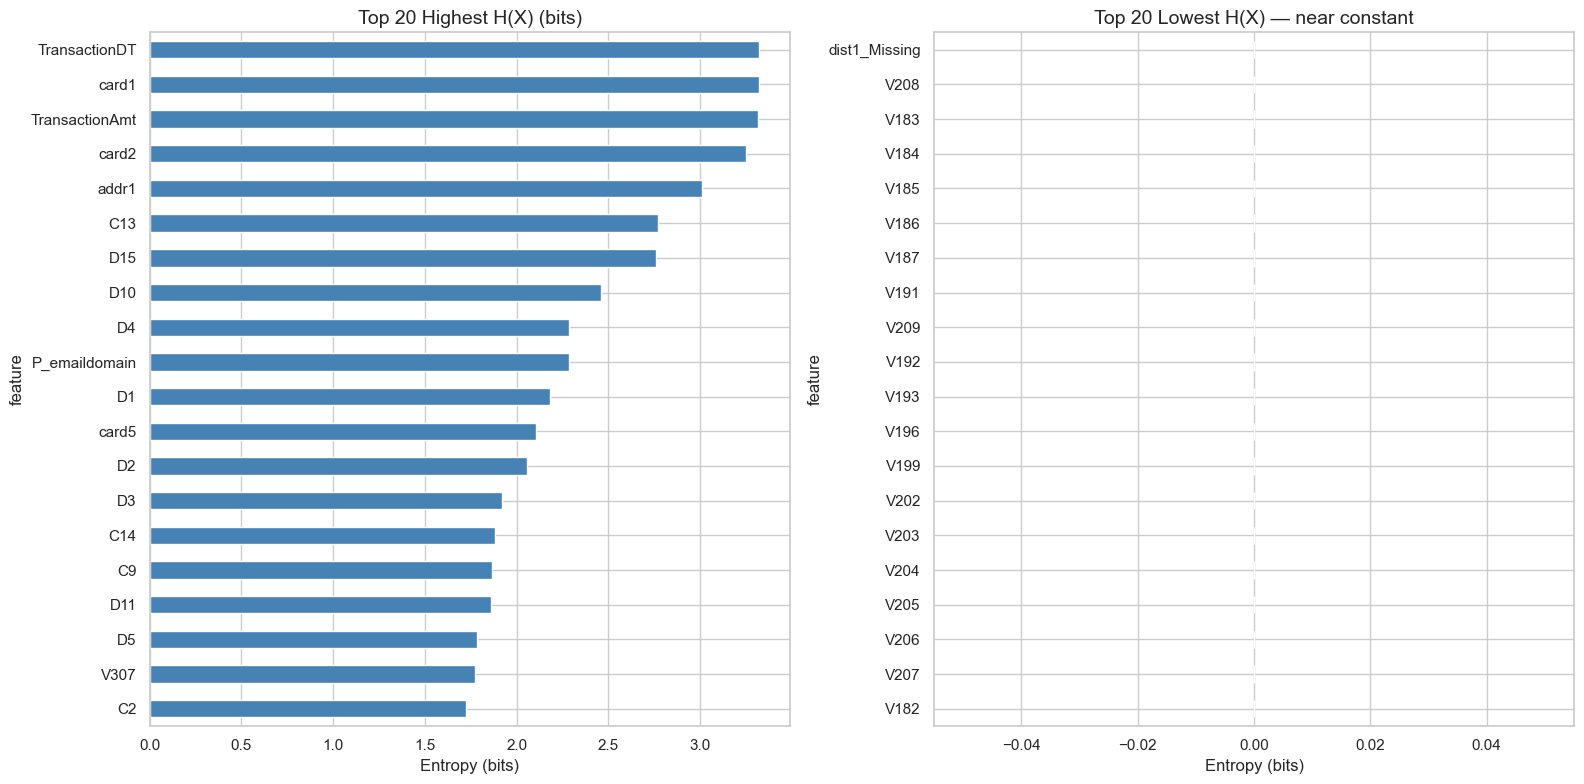

In [185]:
# -- D3.2 Feature entropy H(X) for all features ──
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
X_disc = kbd.fit_transform(X_info).astype(int)

H_x = {}
for j, col in enumerate(feat_names):
    counts = np.bincount(X_disc[:, j])
    counts = counts[counts > 0]
    H_x[col] = entropy(counts, base=2)

H_df = pd.DataFrame({'feature': list(H_x.keys()), 'entropy_bits': list(H_x.values())})
H_df = H_df.sort_values('entropy_bits', ascending=False)

print('Top 20 features by entropy H(X) — highest uncertainty / spread:')
display(H_df.head(TOP_N).round(4))
print('\nTop 20 features by LOWEST entropy — near-constant (candidates to drop):')
display(H_df.tail(TOP_N).sort_values('entropy_bits').round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
H_df.head(TOP_N).sort_values('entropy_bits').plot(
    kind='barh', x='feature', y='entropy_bits', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title(f'Top {TOP_N} Highest H(X) (bits)')
axes[0].set_xlabel('Entropy (bits)')

H_df.tail(TOP_N).sort_values('entropy_bits').plot(
    kind='barh', x='feature', y='entropy_bits', ax=axes[1], color='coral', legend=False)
axes[1].set_title(f'Top {TOP_N} Lowest H(X) — near constant')
axes[1].set_xlabel('Entropy (bits)')
plt.tight_layout()
plt.show()


Computing mutual information for all features (may take 1–3 min)…

Top 20 features by Mutual Information with isFraud:


,feature,MI
253,V201,0.035600
241,V189,0.034772
251,V199,0.034637
295,V243,0.032416
309,V257,0.031869
311,V259,0.031702
242,V190,0.031331
252,V200,0.031274
310,V258,0.030885
222,V170,0.030136


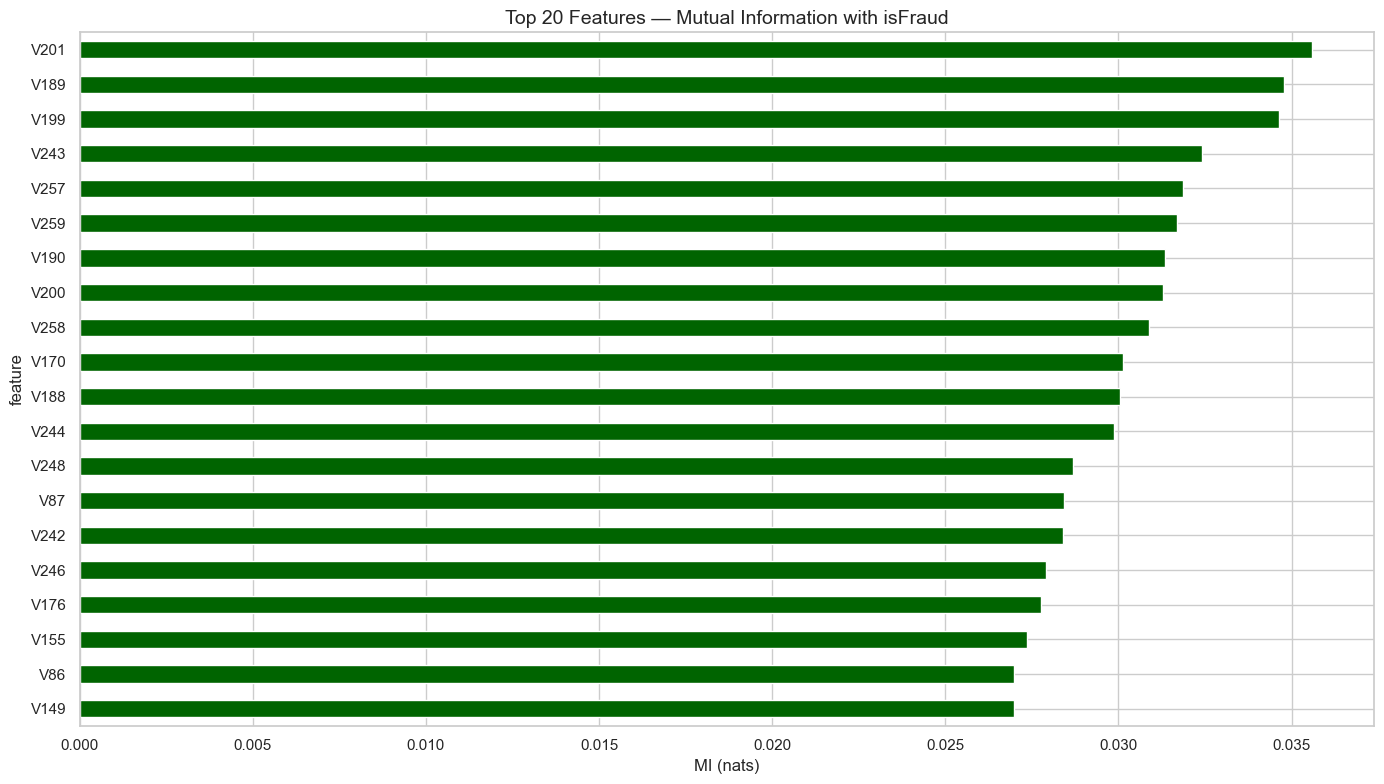


Overlap: Pearson top-15 (D3.1) vs MI top-15 (D4.3):


,Set,Count,Examples
0,In BOTH top-15,10,"V170, V188, V189, V200, V201, V242, V244, V257…"
1,Pearson only,5,"V228, V246, V44, V45, V86"
2,MI only,5,"V190, V199, V243, V248, V259"


In [154]:
# -- D4.3 Mutual Information I(X;Y) — full ranking ──
print('Computing mutual information for all features (may take 1–3 min)…')
mi_scores = mutual_info_classif(X_info, y_info, random_state=42)
mi_df = pd.DataFrame({'feature': feat_names, 'MI': mi_scores}).sort_values('MI', ascending=False)

print(f'\nTop {TOP_N} features by Mutual Information with isFraud:')
display(mi_df.head(TOP_N).round(6))

fig, ax = plt.subplots(figsize=(14, 8))
mi_df.head(TOP_N).sort_values('MI').plot(
    kind='barh', x='feature', y='MI', ax=ax, color='darkgreen', legend=False)
ax.set_title(f'Top {TOP_N} Features — Mutual Information with isFraud', fontsize=14)
ax.set_xlabel('MI (nats)')
plt.tight_layout()
plt.show()

# Overlap: Pearson (D3.1) vs MI top-15
pearson_rank = X_info.corrwith(y_info).dropna().abs().sort_values(ascending=False)
top_pearson = set(pearson_rank.head(15).index)
top_mi = set(mi_df.head(15)['feature'])
both = top_pearson & top_mi
only_pearson = top_pearson - top_mi
only_mi = top_mi - top_pearson

overlap_tbl = pd.DataFrame({
    'Set': ['In BOTH top-15', 'Pearson only', 'MI only'],
    'Count': [len(both), len(only_pearson), len(only_mi)],
    'Examples': [
        ', '.join(sorted(both)[:8]) + ('…' if len(both) > 8 else ''),
        ', '.join(sorted(only_pearson)[:5]) or '—',
        ', '.join(sorted(only_mi)[:5]) or '—',
    ]
})
print('\nOverlap: Pearson top-15 (D3.1) vs MI top-15 (D4.3):')
display(overlap_tbl)


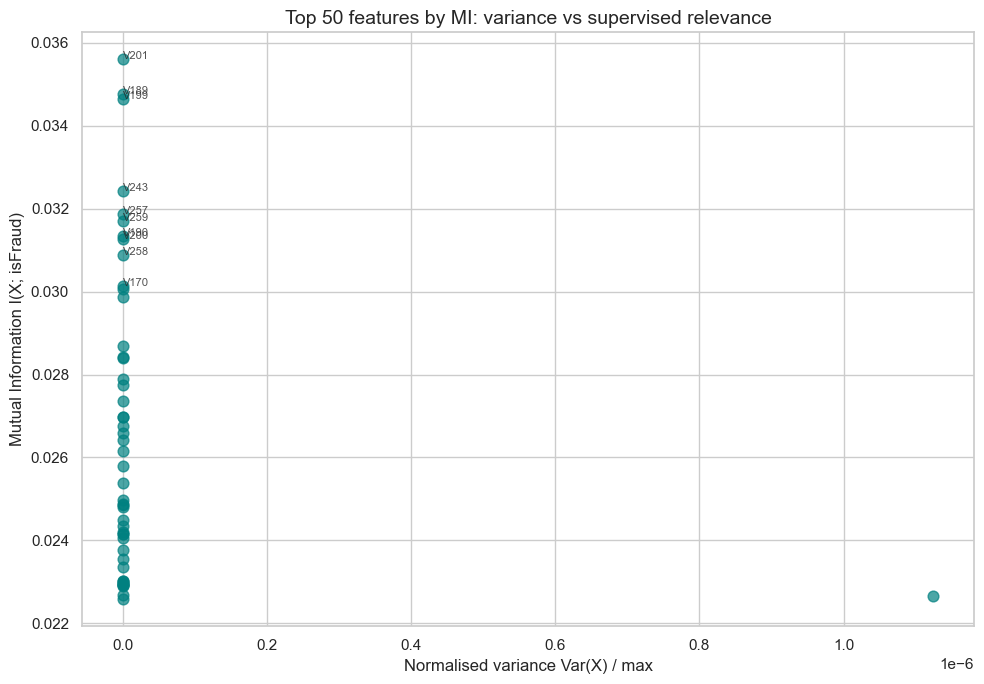

Features with LOW variance but HIGH MI (MI finds signal variance misses):
feature  variance_norm       MI
   V201   2.806455e-14 0.035600
   V189   8.630707e-15 0.034772
   V199   3.517952e-14 0.034637
   V243   2.922107e-14 0.032416
   V257   1.881855e-14 0.031869

Features with HIGH variance but LOW MI (spread without fraud signal):
      feature  variance_norm       MI
TransactionDT            1.0 0.006837


In [155]:
# -- D4.4 Variance vs MI — high variance ≠ high relevance ──
var_scores = X_info.var()
cmp_df = pd.DataFrame({
    'feature': feat_names,
    'variance_norm': var_scores / var_scores.max(),
    'MI': mi_scores,
}).sort_values('MI', ascending=False)

top50 = cmp_df.head(50)
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(top50['variance_norm'], top50['MI'], alpha=0.7, s=60, c='teal')
for _, row in top50.head(10).iterrows():
    ax.annotate(row['feature'], (row['variance_norm'], row['MI']), fontsize=8, alpha=0.8)
ax.set_xlabel('Normalised variance Var(X) / max')
ax.set_ylabel('Mutual Information I(X; isFraud)')
ax.set_title('Top 50 features by MI: variance vs supervised relevance')
plt.tight_layout()
plt.show()

low_var_high_mi = cmp_df[(cmp_df['variance_norm'] < 0.05) & (cmp_df['MI'] > cmp_df['MI'].quantile(0.9))]
high_var_low_mi = cmp_df[(cmp_df['variance_norm'] > 0.5) & (cmp_df['MI'] < cmp_df['MI'].median())]
print('Features with LOW variance but HIGH MI (MI finds signal variance misses):')
print(low_var_high_mi.head(5)[['feature', 'variance_norm', 'MI']].to_string(index=False) if len(low_var_high_mi) else '  (none in top quantile)')
print('\nFeatures with HIGH variance but LOW MI (spread without fraud signal):')
print(high_var_low_mi.head(5)[['feature', 'variance_norm', 'MI']].to_string(index=False) if len(high_var_low_mi) else '  (none)')


#### D4.5 — ReliefF: nearest hit vs nearest miss (paper §d)

```mermaid
flowchart LR
    inst[Instance x]
    hit[Nearest HIT same class]
    miss[Nearest MISS other class]
    inst -->|"same value on good feature"| hit
    inst -->|"different value on good feature"| miss
```

ReliefF increases weight when a feature differs from the nearest miss but matches the nearest hit. Full evaluation with cross-validation is in **A2 Section D4**.


Running ReliefF preview on n=6,799…


,feature,ReliefF_weight
310,V258,0.057343
309,V257,0.050495
8,card6,0.050133
46,M3,0.048554
169,V117,0.047032
298,V246,0.046958
202,V150,0.046023
171,V119,0.043664
50,M7,0.041934
170,V118,0.040845


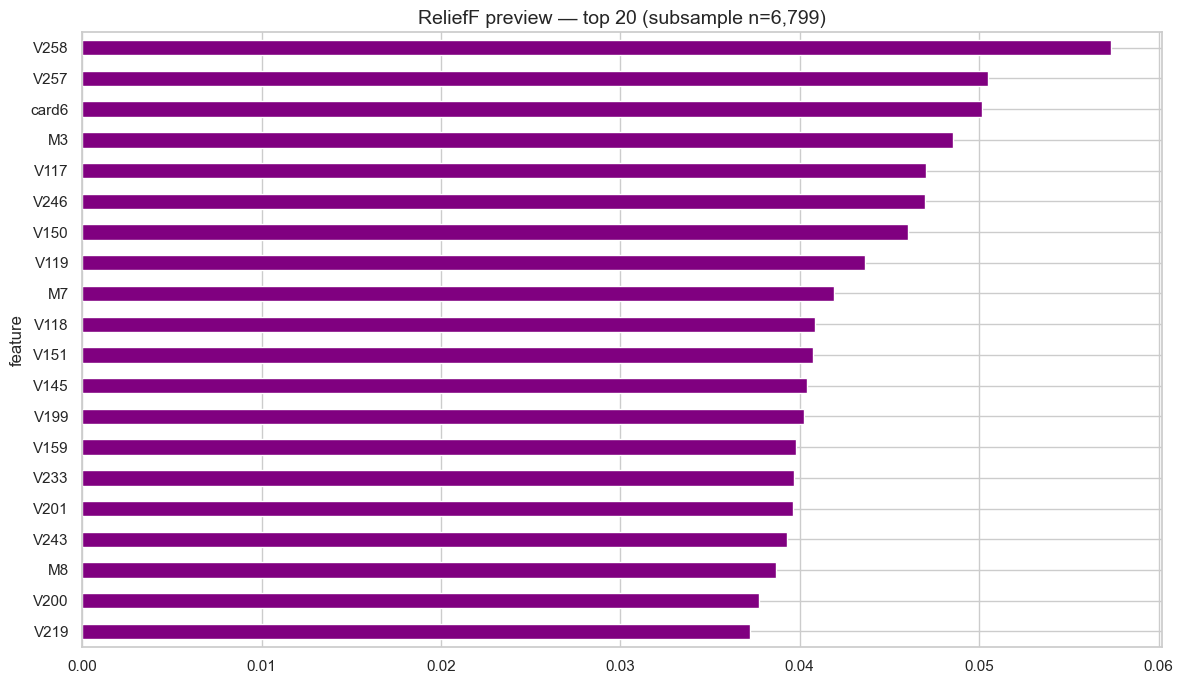

In [156]:
# -- D4.5 ReliefF preview (8K subsample) ──
def relieff_preview(X_arr, y_arr, n_neighbors=10):
    n, p = X_arr.shape
    W = np.zeros(p)
    y_arr = np.asarray(y_arr)
    for i in range(n):
        xi, ci = X_arr[i], y_arr[i]
        same = y_arr == ci
        same[i] = False
        diff = ~same
        dh = np.sqrt(((X_arr[same] - xi) ** 2).sum(axis=1))
        dm = np.sqrt(((X_arr[diff] - xi) ** 2).sum(axis=1))
        kh, km = min(n_neighbors, dh.size), min(n_neighbors, dm.size)
        if kh == 0 or km == 0:
            continue
        hits = X_arr[same][np.argsort(dh)[:kh]]
        misses = X_arr[diff][np.argsort(dm)[:km]]
        W -= np.abs(xi - hits).mean(axis=0) / n
        W += np.abs(xi - misses).mean(axis=0) / n
    return W

RELIEF_N = 8_000
idx_rf = y_info.groupby(y_info, group_keys=False).apply(
    lambda g: g.sample(min(len(g), RELIEF_N // 2), random_state=42)
).index
from sklearn.preprocessing import StandardScaler
X_rf = StandardScaler().fit_transform(X_info.loc[idx_rf])
y_rf = y_info.loc[idx_rf].values
print(f'Running ReliefF preview on n={len(idx_rf):,}…')
relief_w = relieff_preview(X_rf, y_rf)
relief_df = pd.DataFrame({'feature': feat_names, 'ReliefF_weight': relief_w}).sort_values(
    'ReliefF_weight', ascending=False)

display(relief_df.head(TOP_N).round(6))
fig, ax = plt.subplots(figsize=(12, 7))
relief_df.head(TOP_N).sort_values('ReliefF_weight').plot(
    kind='barh', x='feature', y='ReliefF_weight', ax=ax, color='purple', legend=False)
ax.set_title(f'ReliefF preview — top {TOP_N} (subsample n={len(idx_rf):,})')
plt.tight_layout()
plt.show()


**D4 conclusion:** Target entropy confirms severe imbalance. Feature entropy H(X) flags near-constant columns. **MI** ranks V-features (V257, V244, V242) among the strongest fraud signals — overlapping with but not identical to Pearson (D3.1). **Variance alone** does not imply predictive power (D4.4). ReliefF preview (D4.5) highlights complementary neighbours-based weights. Assignment 2 applies Pearson, MI, ReliefF, and multivariate filters as formal selection methods with Logistic Regression + CV.


### D5 - Bivariate redundancy — Spearman among numerics

D3 and D4 identify fraud-related features **one at a time**. D5 checks **feature–feature** redundancy among numerics using Spearman correlation — input for multivariate selection in Assignment 2.

In this section, I analyze the relationships between selected numerical variables. I use Spearman correlation because many numerical variables are highly skewed and contain outliers.

The heatmap gives a general view of numerical relationships. I also include scatter plots for selected pairs: `TransactionAmt` vs `TransactionDT`, `C1` vs `C2`, and `V101` vs `V103`. These plots help identify weak and strong numerical relationships for feature selection and dimensionality reduction.

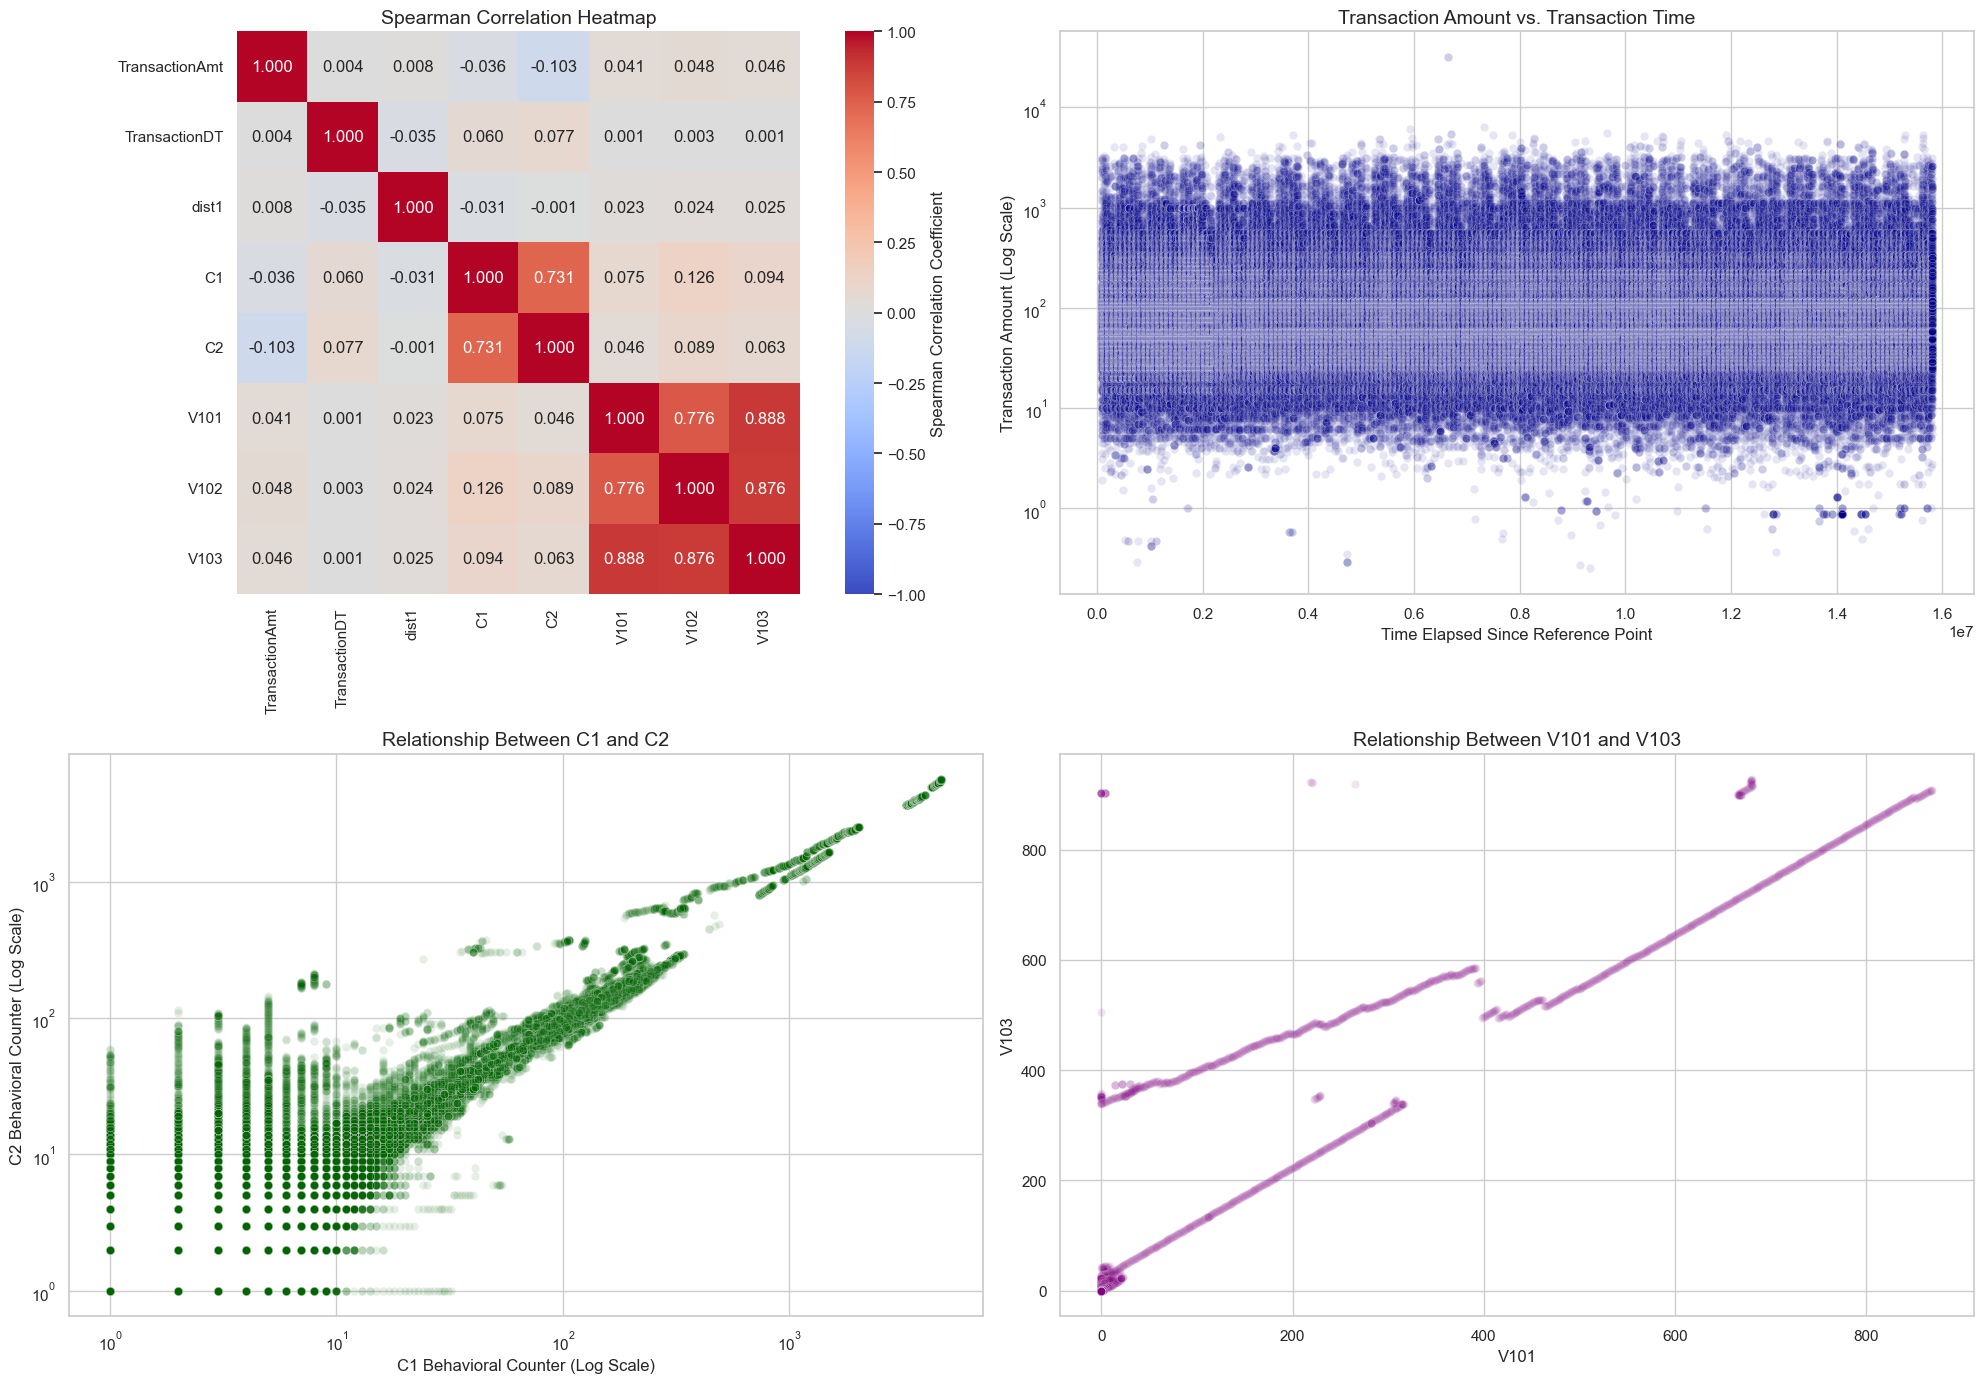

,TransactionAmt,TransactionDT,dist1,C1,C2,V101,V102,V103
TransactionAmt,1.000000,0.004376,0.008207,-0.036327,-0.102936,0.040926,0.048244,0.045681
TransactionDT,0.004376,1.000000,-0.035373,0.059524,0.077185,0.001107,0.003103,0.001018
dist1,0.008207,-0.035373,1.000000,-0.031019,-0.001004,0.022776,0.023722,0.025251
C1,-0.036327,0.059524,-0.031019,1.000000,0.731220,0.075363,0.126438,0.094154
C2,-0.102936,0.077185,-0.001004,0.731220,1.000000,0.046058,0.088837,0.063186
V101,0.040926,0.001107,0.022776,0.075363,0.046058,1.000000,0.775699,0.887543
V102,0.048244,0.003103,0.023722,0.126438,0.088837,0.775699,1.000000,0.876150
V103,0.045681,0.001018,0.025251,0.094154,0.063186,0.887543,0.876150,1.000000


In [157]:
# Section D: Exploratory Data Analysis
# Subsection: D5 - Bivariate redundancy — Spearman among numerics

# 1. Define numerical features consistent with D1
numerical_subset = [
    'TransactionAmt', 
    'TransactionDT',
    'dist1',
    'C1', 
    'C2',
    'V101', 
    'V102', 
    'V103'
]

# Keep only columns that exist in the dataframe
valid_numerical_features = [
    col for col in numerical_subset 
    if col in df_train.columns
]

# 2. Compute the Spearman Rank Correlation Matrix
correlation_matrix = df_train[valid_numerical_features].corr(method='spearman')

# 3. Create visualization layout
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Plot A: Spearman correlation heatmap
sns.heatmap(
    data=correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0, 0],
    cbar_kws={"label": "Spearman Correlation Coefficient"}
)

axes[0, 0].set_title("Spearman Correlation Heatmap")

# Plot B: TransactionAmt vs TransactionDT
sns.scatterplot(
    data=df_train, 
    x='TransactionDT', 
    y='TransactionAmt', 
    alpha=0.1, 
    ax=axes[0, 1], 
    color='darkblue'
)

axes[0, 1].set_yscale('log')
axes[0, 1].set_title("Transaction Amount vs. Transaction Time")
axes[0, 1].set_xlabel("Time Elapsed Since Reference Point")
axes[0, 1].set_ylabel("Transaction Amount (Log Scale)")

# Plot C: Strong relationship between C1 and C2
sns.scatterplot(
    data=df_train, 
    x='C1', 
    y='C2', 
    alpha=0.1, 
    ax=axes[1, 0], 
    color='darkgreen'
)

axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Relationship Between C1 and C2")
axes[1, 0].set_xlabel("C1 Behavioral Counter (Log Scale)")
axes[1, 0].set_ylabel("C2 Behavioral Counter (Log Scale)")

# Plot D: Strong relationship between V101 and V103
sns.scatterplot(
    data=df_train, 
    x='V101', 
    y='V103', 
    alpha=0.1, 
    ax=axes[1, 1], 
    color='purple'
)

axes[1, 1].set_title("Relationship Between V101 and V103")
axes[1, 1].set_xlabel("V101")
axes[1, 1].set_ylabel("V103")

plt.tight_layout()
plt.show()

# 4. Display correlation matrix
display(correlation_matrix)

**Conclusion:**  
`C1` and `C2` have a strong positive relationship. This means they may describe similar transaction behavior and could contain repeated information. Combined with V-feature redundancy in D3.1, this supports multivariate feature selection in Assignment 2.

`V101`, `V102`, and `V103` also show strong positive correlations, especially `V101` with `V103`. These variables may also be redundant, so they could be useful candidates for feature selection or PCA.

`TransactionAmt`, `TransactionDT`, and `dist1` have weak correlations with most selected variables. This suggests that they provide different information and should be analyzed separately.

## Section E: Problem Formulation

The goal of this project is to predict whether a transaction is fraudulent or legitimate. The target variable is `isFraud`, where 1 means fraud and 0 means non-fraud.

This is a supervised binary classification problem because the dataset already contains the correct label for each transaction. The model would use transaction information, card information, product category, device information, and other behavioral variables to estimate the probability of fraud.

The main challenge is class imbalance (~3.5% fraud). Target entropy H(isFraud) is well below 1 bit (Section D4), so accuracy alone is not a good metric. Better evaluation metrics include precision, recall, F1-score, ROC-AUC, and **PR-AUC**.

The EDA shows several fraud signals:
- **V-features** (V257, V244, V242) rank highest by Pearson correlation (D3.1/D3.2a) and mutual information (D4.3).
- **DeviceType missingness** differs by class (Sections C and D3.2a) — missing identity data is informative.
- **Categorical** variables (`ProductCD`, `card4`, `card6`, `DeviceType`) show significant Chi-square association with fraud (D3.2c).
- **Variance alone** does not guarantee relevance to fraud; MI provides a supervised information-theoretic ranking (D4.4).
- **Redundancy** among top V-features (D3.1 heatmap, D5 Spearman) motivates multivariate feature selection in Assignment 2.

**Assignment 2** will apply these insights using formal univariate filters (Pearson, ANOVA, Chi-square, ReliefF, MI), multivariate filters (CFS, CON, DISR), and PCA — with cross-validated Logistic Regression to select the best method for this fraud-detection task.


## Requirements

This notebook was developed in Python. To reproduce the analysis, place `train_transaction.csv` and `train_identity.csv` in the same folder as this notebook and run all cells from top to bottom.

Main libraries used:
- pandas
- numpy
- matplotlib
- seaborn
- scipy
- missingno
- scikit-learn


B0 exports `feature_profile_434.html` — no extra packages required.

In [158]:
import sys
import scipy
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("missingno:", msno.__version__)

Python: 3.10.8 (tags/v3.10.8:aaaf517, Oct 11 2022, 16:50:30) [MSC v.1933 64 bit (AMD64)]
pandas: 2.3.0
numpy: 1.26.4
matplotlib: 3.10.3
seaborn: 0.13.2
scipy: 1.14.0
missingno: 0.5.2
